# Para este código funcionar, utilize Python 3.11 com venv para criar um ambiente virtual.
# 🎓 Pipeline Completo de Machine Learning — TCC
## Sistema de Predição com ML Integrado (PyCaret + Scikit-Learn)

**Projeto:** GlicNutri  
**Equipe:** [Fernando Santos, Caio Bueno, Mateus Costa, João Ricardo, Gustavo Ribeiro]  
**Instituição:** [UniCesumar]  
**Data:** 2026

---

### Sumário

1. **Instalação e Configuração**
2. **Carregamento e Validação do Dataset**
3. **Análise Exploratória de Dados (EDA)**
4. **Pré-processamento e Preparação dos Dados**
5. **Pipeline 1 — Classificação**
6. **Pipeline 2 — Regressão**
7. **Pipeline 3 — Clusterização**
8. **Pipeline 4 — Sistema de Similaridade entre Pacientes**
9. **Persistência dos Modelos**
10. **Conclusões**


---

### Dataset Escolhido: Pima Indians Diabetes Dataset

O dataset **Pima Indians Diabetes** contém dados clínicos de pacientes do sexo feminino de ascendência Pima, com o objetivo de analisar fatores associados ao diagnóstico de diabetes.  
Ele é ideal para este trabalho, pois permite adaptar os **4 tipos de problema** exigidos no projeto:

| Problema | Abordagem |
|---|---|
| **Classificação** | Prever se a paciente possui diabetes (**Outcome**) ou não |
| **Regressão** | Prever o valor da glicose (**Glucose**) com base nas demais variáveis clínicas |
| **Clusterização** | Agrupar pacientes por perfil clínico e metabólico |
| **Similaridade** | Encontrar pacientes semelhantes com base nas características clínicas |

---

### Variáveis do dataset

O dataset é composto pelas seguintes variáveis:

- **Pregnancies** — número de gestações  
- **Glucose** — concentração de glicose no plasma  
- **BloodPressure** — pressão arterial diastólica  
- **SkinThickness** — espessura da dobra cutânea do tríceps  
- **Insulin** — nível de insulina sérica  
- **BMI** — índice de massa corporal  
- **DiabetesPedigreeFunction** — histórico familiar/genético de diabetes  
- **Age** — idade da paciente  
- **Outcome** — variável alvo da classificação (0 = sem diabetes, 1 = com diabetes)

---

### Objetivo do projeto

O objetivo deste trabalho é construir um pipeline completo de machine learning utilizando o dataset **Pima Indians Diabetes**, integrando técnicas de:

- **classificação supervisionada**;
- **regressão supervisionada**;
- **clusterização não supervisionada**;
- **análise de similaridade entre pacientes**;
- **persistência e reaproveitamento dos modelos treinados**.

O projeto busca demonstrar, de forma prática, a aplicação de diferentes técnicas de aprendizado de máquina em um mesmo contexto de dados clínicos.

---
## 1. Instalação e Configuração

In [ ]:
# ============================================================
# CÉLULA 1 — Instalação das dependências
# Execute esta célula e reinicie o runtime quando solicitado
# ============================================================

!pip install pycaret[full]==3.3.2 --quiet
!pip install kagglehub[pandas-datasets] --quiet
!pip install openpyxl --quiet

print("✅ Instalação concluída! Se houver aviso, reinicie o runtime (Menu > Runtime > Restart).")

✅ Instalação concluída! Se houver aviso, reinicie o runtime (Menu > Runtime > Restart).


In [ ]:
# ============================================================
# CÉLULA 2 — Imports gerais
# ============================================================

import warnings
warnings.filterwarnings('ignore')

import os
os.environ["PYCARET_CUSTOM_LOGGING_LEVEL"] = "CRITICAL"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Configurações de visualização
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

import pycaret

print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"PyCaret: {pycaret.__version__}")

print("\n✅ Imports carregados com sucesso!")

NumPy: 1.26.4
Pandas: 2.1.4
PyCaret: 3.3.2

✅ Imports carregados com sucesso!


---
## 2. Carregamento e Validação do Dataset

### 2.1 Ingestão dos Dados

O dataset **Pima Indians Diabetes** foi obtido a partir do **Kaggle** e contém
informações clínicas utilizadas para análise e predição de diabetes.

Nesta etapa, o objetivo é realizar o carregamento do dataset e as verificações
iniciais de integridade, estrutura, tipos de dados e consistência das variáveis,
conforme exigido na especificação do projeto.

In [ ]:
# ============================================================
# CÉLULA 3 — Carregamento do Dataset Pima Indians Diabetes
# ============================================================

import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "diabetes.csv"

try:
    print("⏳ Carregando dataset do Kaggle...")

    df_raw = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        "jamaltariqcheema/pima-indians-diabetes-dataset",
        file_path
    )

    print("📥 Dataset: Pima Indians Diabetes Dataset")
    print(f"✅ Dataset carregado com sucesso: {df_raw.shape[0]} linhas e {df_raw.shape[1]} colunas")
    display(df_raw.head())

except Exception as e:
    print(f"⚠️ Erro ao carregar dataset: {e}")
    print("\n📌 Alternativa: faça upload manual do arquivo diabetes.csv")
    raise

⏳ Carregando dataset do Kaggle...
📥 Dataset: Pima Indians Diabetes Dataset
✅ Dataset carregado com sucesso: 768 linhas e 9 colunas


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.00,35,169.50,33.60,0.63,50,1
1,1,85,66.00,29,102.50,26.60,0.35,31,0
2,8,183,64.00,32,169.50,23.30,0.67,32,1
3,1,89,66.00,23,94.00,28.10,0.17,21,0
4,0,137,40.00,35,168.00,43.10,2.29,33,1


In [ ]:
# ============================================================
# CÉLULA 4 — Validação inicial do dataset
# ============================================================

print("=" * 60)
print("VALIDAÇÃO INICIAL DO DATASET")
print("=" * 60)

# 1. Identificação das colunas
print("\n📋 Colunas identificadas:")
for i, col in enumerate(df_raw.columns, start=1):
    print(f"   {i}. {col}")

# 2. Tipos de dados
print("\n📊 Tipos de dados detectados:")
print(df_raw.dtypes.to_string())

# 3. Verificação de integridade estrutural
print(f"\n📏 Dimensão do dataset: {df_raw.shape}")
print(f"📈 Total de registros: {df_raw.shape[0]}")
print(f"📊 Total de colunas: {df_raw.shape[1]}")

# 4. Valores nulos
print("\n🔍 Valores nulos por coluna:")
null_counts = df_raw.isnull().sum()
null_pct = (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
null_summary = pd.DataFrame({
    'Nulos': null_counts,
    '% do Total': null_pct
})
print(null_summary.to_string())

# 5. Registros duplicados
duplicados = df_raw.duplicated().sum()
print(f"\n🔄 Registros duplicados: {duplicados} ({duplicados/len(df_raw)*100:.2f}%)")

# 6. Verificação de valores zero potencialmente inválidos
# No dataset Pima, zeros em algumas variáveis clínicas podem representar dados ausentes/inválidos
colunas_zero_invalidas = [
    'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI'
]

print("\n⚠️ Possíveis valores inválidos (zeros) em variáveis clínicas:")
for col in colunas_zero_invalidas:
    if col in df_raw.columns:
        qtd_zeros = (df_raw[col] == 0).sum()
        pct_zeros = (qtd_zeros / len(df_raw) * 100)
        print(f"   {col}: {qtd_zeros} valores iguais a 0 ({pct_zeros:.2f}%)")

# 7. Resumo estatístico
print("\n📈 Resumo estatístico das variáveis numéricas:")
print(df_raw.describe().to_string())

# 8. Amostra inicial
print("\n📋 Primeiras 5 linhas do dataset:")
display(df_raw.head())

print("\n✅ Validação inicial concluída com sucesso.")

VALIDAÇÃO INICIAL DO DATASET

📋 Colunas identificadas:
   1. Pregnancies
   2. Glucose
   3. BloodPressure
   4. SkinThickness
   5. Insulin
   6. BMI
   7. DiabetesPedigreeFunction
   8. Age
   9. Outcome

📊 Tipos de dados detectados:
Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64

📏 Dimensão do dataset: (768, 9)
📈 Total de registros: 768
📊 Total de colunas: 9

🔍 Valores nulos por coluna:
                          Nulos  % do Total
Pregnancies                   0        0.00
Glucose                       0        0.00
BloodPressure                 0        0.00
SkinThickness                 0        0.00
Insulin                       0        0.00
BMI                           0        0.00
DiabetesPedigreeFuncti

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.00,35,169.50,33.60,0.63,50,1
1,1,85,66.00,29,102.50,26.60,0.35,31,0
2,8,183,64.00,32,169.50,23.30,0.67,32,1
3,1,89,66.00,23,94.00,28.10,0.17,21,0
4,0,137,40.00,35,168.00,43.10,2.29,33,1



✅ Validação inicial concluída com sucesso.


In [ ]:
# ============================================================
# CÉLULA 5 — Estatísticas descritivas
# ============================================================

print("📊 Estatísticas Descritivas — Variáveis Numéricas:")
display(df_raw.describe())

colunas_categoricas = df_raw.select_dtypes(include='object').columns

if len(colunas_categoricas) > 0:
    print("\n📊 Estatísticas Descritivas — Variáveis Categóricas:")
    display(df_raw.describe(include='object'))
else:
    print("\n📊 Variáveis categóricas:")
    print("Nenhuma variável categórica do tipo object foi identificada no dataset.")

print("\n📊 Distribuição da variável alvo (Outcome):")
display(df_raw['Outcome'].value_counts().rename("Contagem"))

print("\n📊 Proporção da variável alvo (Outcome):")
display((df_raw['Outcome'].value_counts(normalize=True) * 100).round(2).rename("Percentual (%)"))0

📊 Estatísticas Descritivas — Variáveis Numéricas:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,121.68,72.39,29.09,141.75,32.43,0.47,33.24,0.35
std,3.37,30.46,12.11,8.89,89.10,6.88,0.33,11.76,0.48
min,0.00,44.00,24.00,7.00,14.00,18.20,0.08,21.00,0.00
25%,1.00,99.75,64.00,25.00,102.50,27.50,0.24,24.00,0.00
50%,3.00,117.00,72.00,28.00,102.50,32.05,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,169.50,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00



📊 Variáveis categóricas:
Nenhuma variável categórica do tipo object foi identificada no dataset.

📊 Distribuição da variável alvo (Outcome):


,Contagem
Outcome,
0,500
1,268



📊 Proporção da variável alvo (Outcome):


,Percentual (%)
Outcome,
0,65.10
1,34.90


---
## 3. Análise Exploratória de Dados (EDA)

O objetivo desta seção é gerar visualizações estatísticas que justifiquem tecnicamente  
a seleção das features utilizadas nos modelos.

In [ ]:
# ============================================================
# CÉLULA 6 — Limpeza inicial para EDA
# ============================================================

# Cópia para não afetar o dataset original
df = df_raw.copy()

print(f"📏 Registros antes da limpeza: {len(df)}")

# No dataset Pima, zeros em algumas variáveis clínicas podem representar
# ausência de medição / valores inválidos
cols_zero_as_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_zero_as_missing:
    if col in df.columns:
        df[col] = df[col].replace(0, np.nan)

# Remover duplicatas, se existirem
duplicados_antes = df.duplicated().sum()
df = df.drop_duplicates()

print(f"🔄 Duplicatas removidas: {duplicados_antes}")
print(f"📏 Registros após remoção de duplicatas: {len(df)}")

# Resumo de valores ausentes após conversão de zeros inválidos
print("\n📊 Valores ausentes após tratar zeros inválidos:")
missing_summary = pd.DataFrame({
    'Ausentes': df.isnull().sum(),
    '% do total': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing_summary.to_string())

print("\n📋 Primeiras linhas após limpeza inicial:")
display(df.head())

print("\n✅ Limpeza inicial concluída.")
print("ℹ️ A imputação dos valores ausentes será feita na etapa de pré-processamento.")

📏 Registros antes da limpeza: 768
🔄 Duplicatas removidas: 0
📏 Registros após remoção de duplicatas: 768

📊 Valores ausentes após tratar zeros inválidos:
                          Ausentes  % do total
Pregnancies                      0        0.00
Glucose                          0        0.00
BloodPressure                    0        0.00
SkinThickness                    0        0.00
Insulin                          0        0.00
BMI                              0        0.00
DiabetesPedigreeFunction         0        0.00
Age                              0        0.00
Outcome                          0        0.00

📋 Primeiras linhas após limpeza inicial:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.00,35,169.50,33.60,0.63,50,1
1,1,85,66.00,29,102.50,26.60,0.35,31,0
2,8,183,64.00,32,169.50,23.30,0.67,32,1
3,1,89,66.00,23,94.00,28.10,0.17,21,0
4,0,137,40.00,35,168.00,43.10,2.29,33,1



✅ Limpeza inicial concluída.
ℹ️ A imputação dos valores ausentes será feita na etapa de pré-processamento.


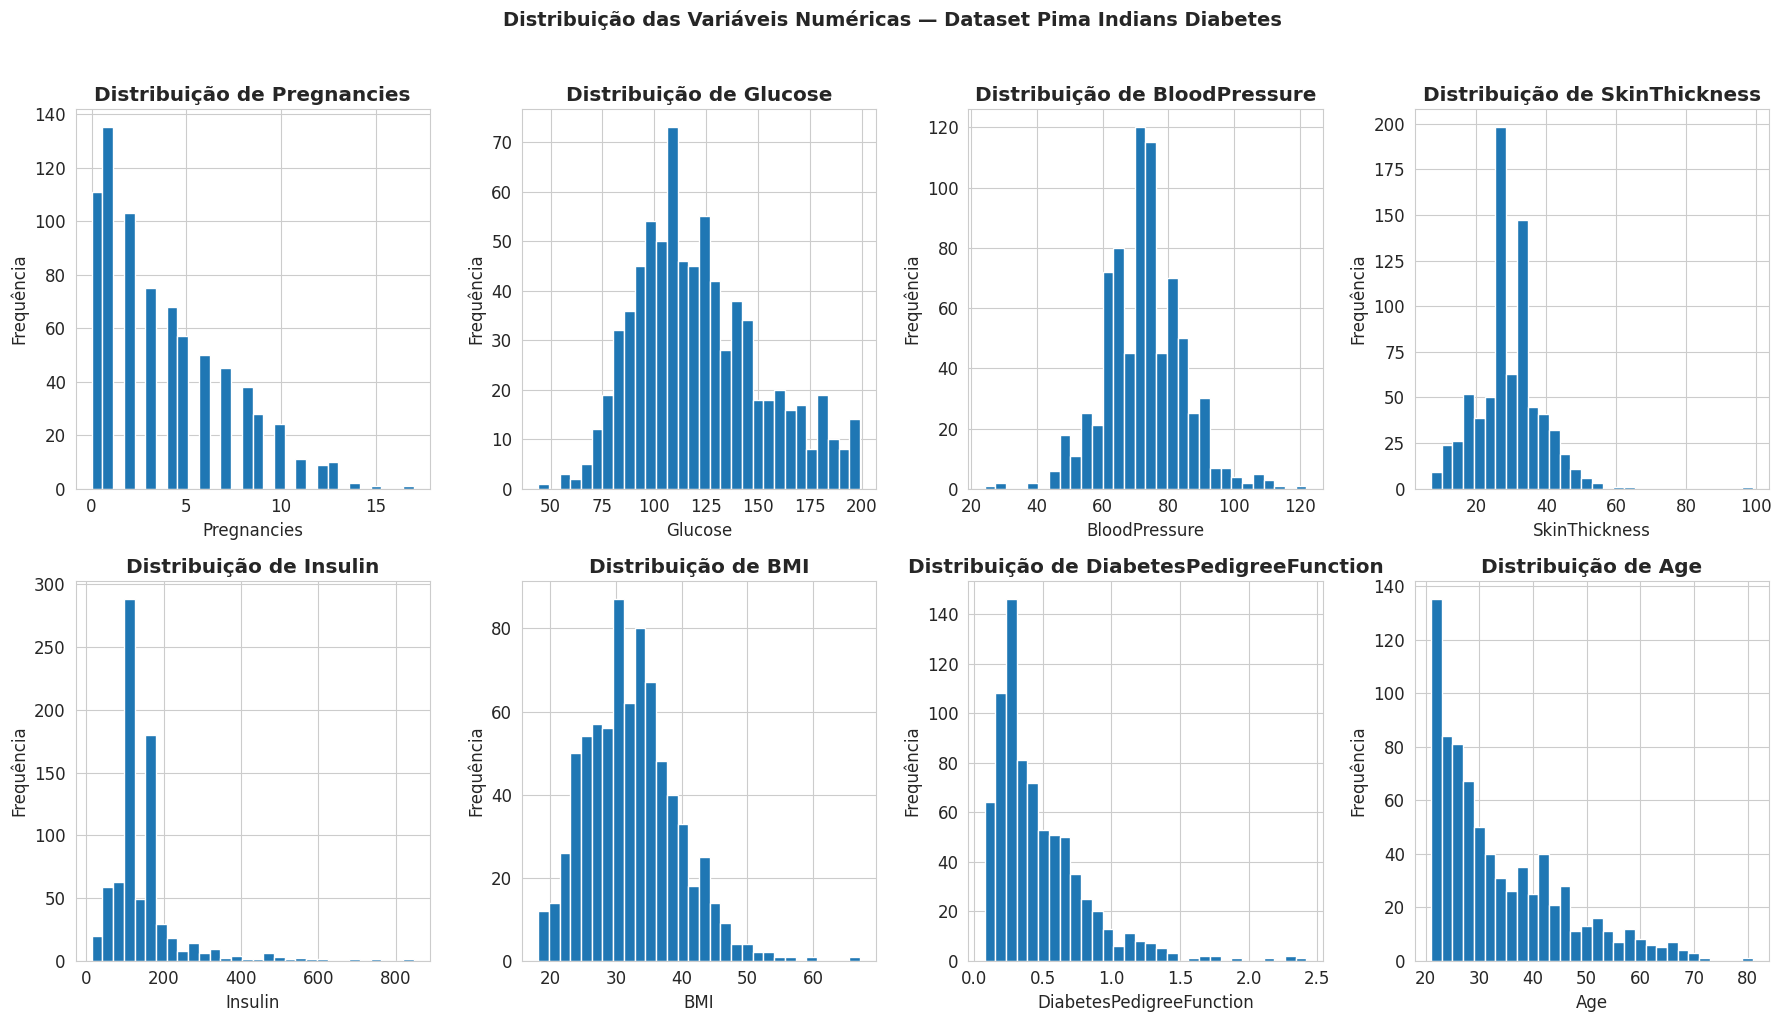

💡 Observação:
   Os histogramas permitem avaliar a distribuição das variáveis,
   além de indicar possível presença de assimetria e valores extremos (outliers).
   Essas características ajudam a justificar o uso de imputação por mediana
   e posterior normalização/padronização no pré-processamento.


In [ ]:
# ============================================================
# CÉLULA 7 — Distribuição das variáveis numéricas (Histogramas)
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

numeric_cols = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
]

for ax, col in zip(axes, numeric_cols):
    df[col].dropna().hist(bins=30, ax=ax, edgecolor='white')
    ax.set_title(f'Distribuição de {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequência')

plt.suptitle('Distribuição das Variáveis Numéricas — Dataset Pima Indians Diabetes',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_histogramas_pima.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 Observação:")
print("   Os histogramas permitem avaliar a distribuição das variáveis,")
print("   além de indicar possível presença de assimetria e valores extremos (outliers).")
print("   Essas características ajudam a justificar o uso de imputação por mediana")
print("   e posterior normalização/padronização no pré-processamento.")

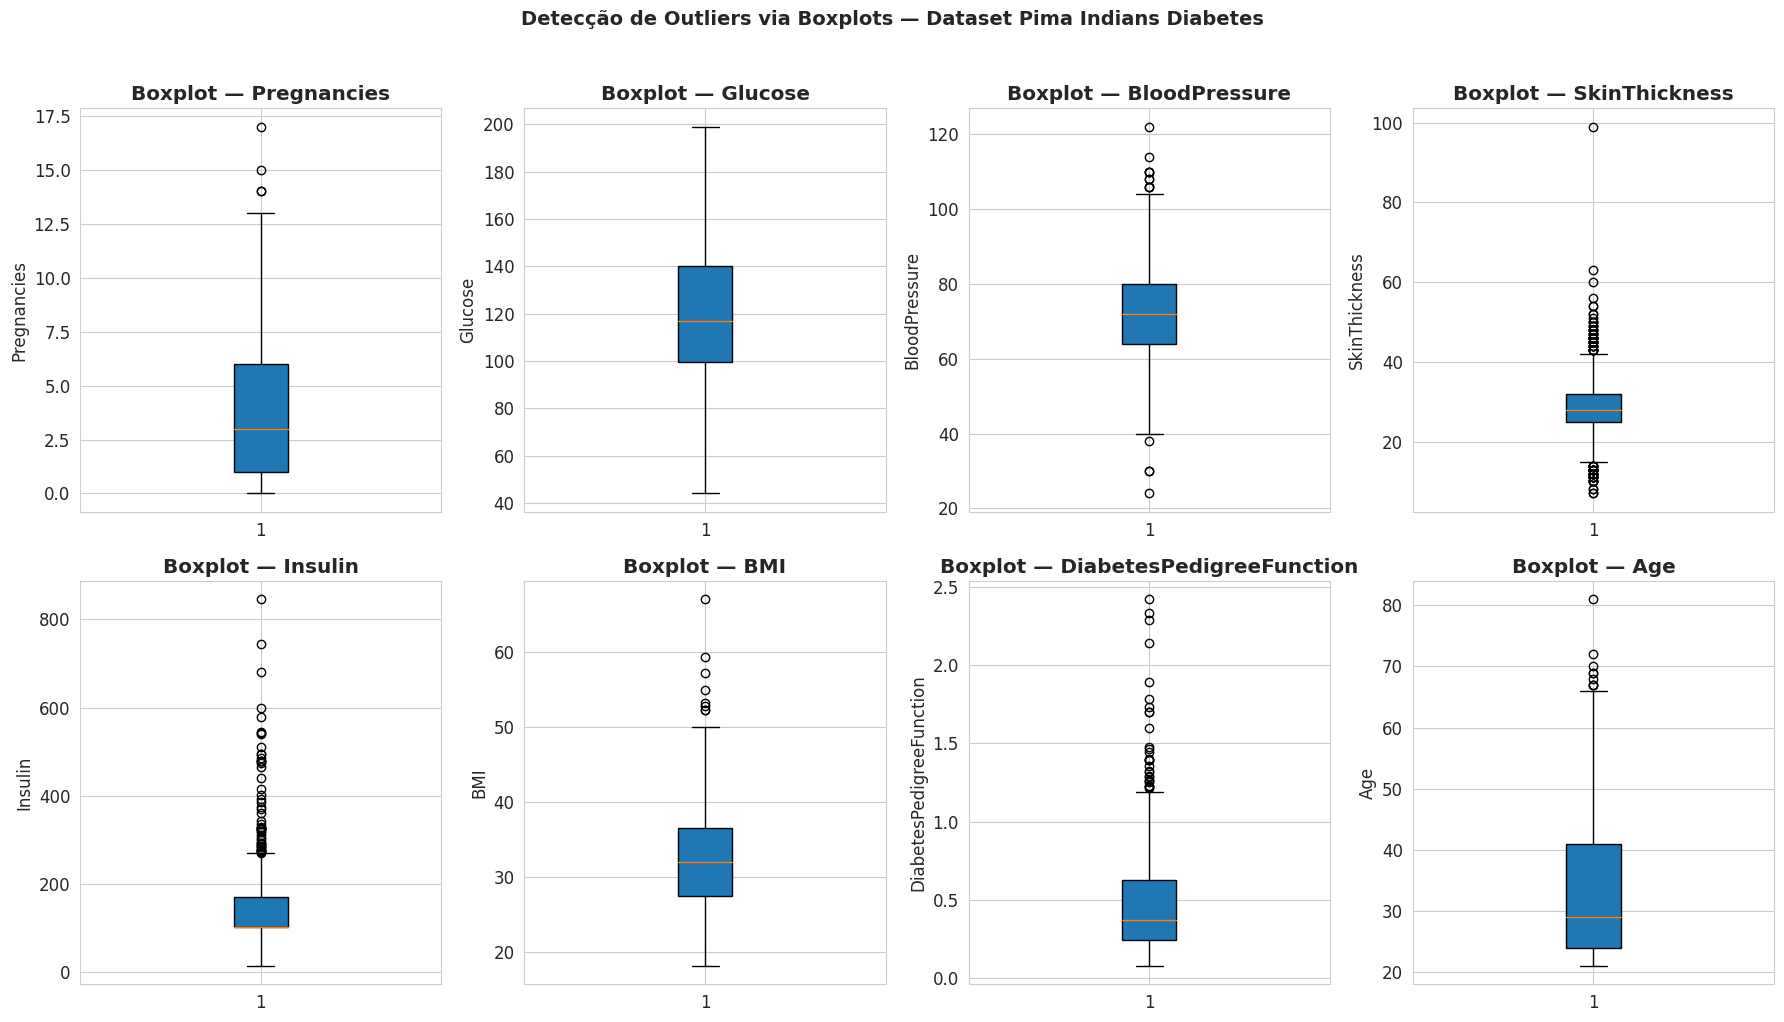

💡 Observação:
   Os boxplots permitem identificar a presença de valores extremos (outliers)
   em variáveis clínicas do dataset, auxiliando na interpretação dos dados
   e na justificativa das etapas de pré-processamento.


In [ ]:
# ============================================================
# CÉLULA 8 — Boxplots para detecção de outliers
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True)
    ax.set_title(f'Boxplot — {col}', fontweight='bold')
    ax.set_ylabel(col)

plt.suptitle('Detecção de Outliers via Boxplots — Dataset Pima Indians Diabetes',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_boxplots_pima.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 Observação:")
print("   Os boxplots permitem identificar a presença de valores extremos (outliers)")
print("   em variáveis clínicas do dataset, auxiliando na interpretação dos dados")
print("   e na justificativa das etapas de pré-processamento.")

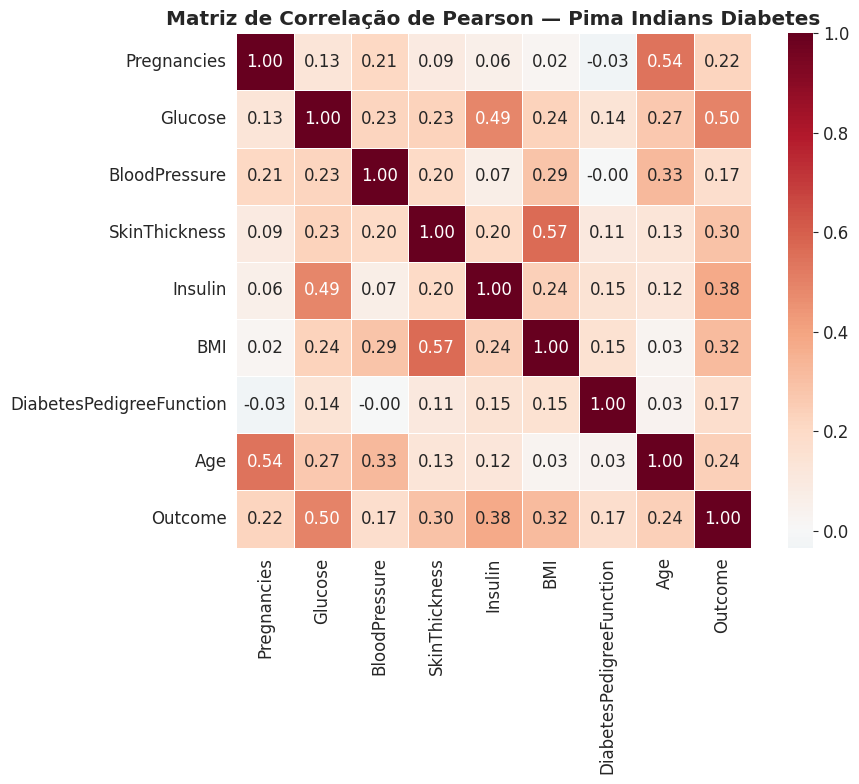

💡 Observação:
   O heatmap permite identificar relações lineares entre as variáveis numéricas,
   ajudando na análise exploratória e na justificativa da seleção de features.


In [ ]:
# ============================================================
# CÉLULA 9 — Heatmap de Correlação (Coeficiente de Pearson)
# ============================================================

corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Matriz de Correlação de Pearson — Pima Indians Diabetes', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_heatmap_correlacao_pima.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 Observação:")
print("   O heatmap permite identificar relações lineares entre as variáveis numéricas,")
print("   ajudando na análise exploratória e na justificativa da seleção de features.")

📊 Distribuição da variável alvo (Outcome):


,Contagem
Outcome,
0,500
1,268



📊 Proporção da variável alvo (Outcome):


,Percentual (%)
Outcome,
0,65.10
1,34.90


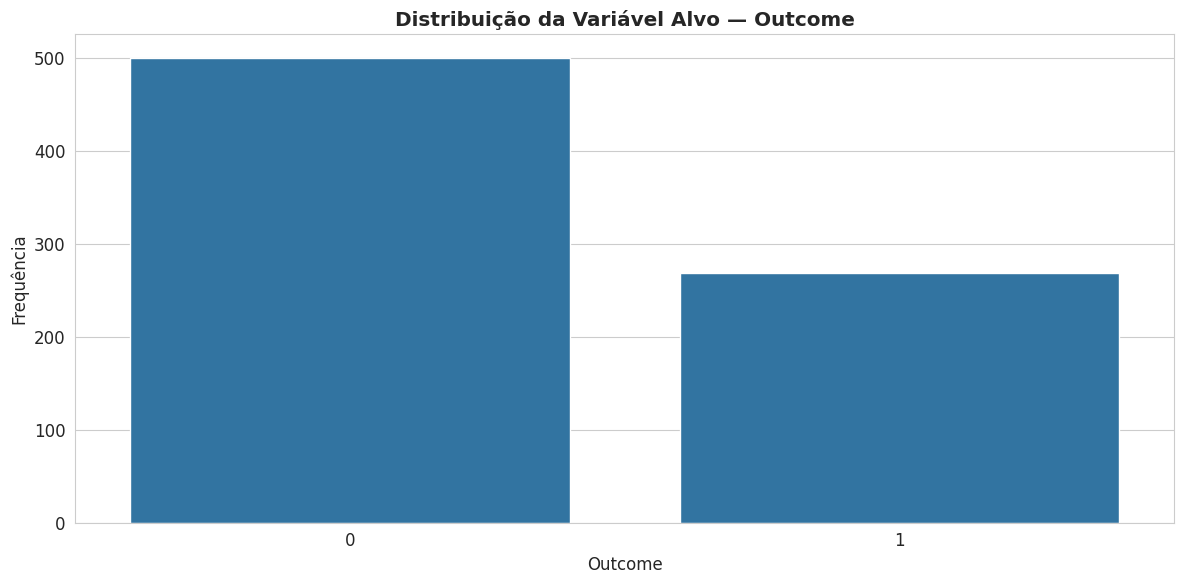

💡 Observação:
   Esta análise permite verificar o balanceamento das classes,
   fator importante para a escolha e interpretação das métricas de classificação.


In [ ]:
# ============================================================
# CÉLULA 10 — Distribuição da variável alvo
# ============================================================

print("📊 Distribuição da variável alvo (Outcome):")
display(df['Outcome'].value_counts().rename("Contagem"))

print("\n📊 Proporção da variável alvo (Outcome):")
display((df['Outcome'].value_counts(normalize=True) * 100).round(2).rename("Percentual (%)"))

sns.countplot(data=df, x='Outcome')
plt.title('Distribuição da Variável Alvo — Outcome', fontweight='bold')
plt.xlabel('Outcome')
plt.ylabel('Frequência')
plt.tight_layout()
plt.savefig('eda_distribuicao_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 Observação:")
print("   Esta análise permite verificar o balanceamento das classes,")
print("   fator importante para a escolha e interpretação das métricas de classificação.")

📊 Importância das Variáveis:


,Feature,Importance
4,Insulin,0.37
1,Glucose,0.16
3,SkinThickness,0.14
7,Age,0.09
5,BMI,0.09
6,DiabetesPedigreeFunction,0.06
2,BloodPressure,0.05
0,Pregnancies,0.05


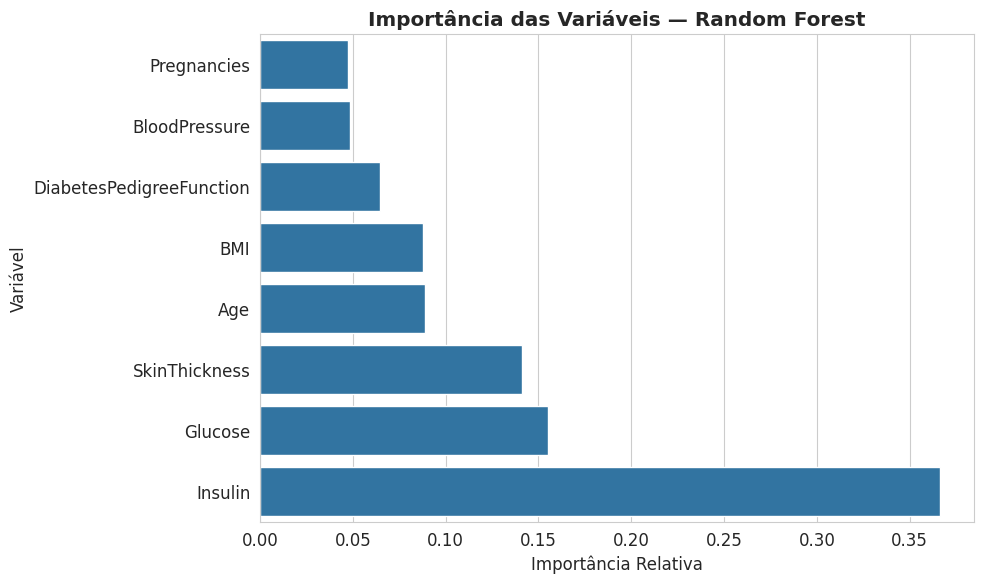

💡 Observação:
   As variáveis com maior importância são as que mais contribuem
   para a predição do desfecho de diabetes no dataset.
   Essa análise ajuda a justificar tecnicamente a escolha das features do modelo.


In [ ]:
# ============================================================
# CÉLULA 11 — Importância das Variáveis (Random Forest)
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer

X_importance = df.drop(columns=['Outcome'])
y_importance = df['Outcome']

# Imputação por mediana para lidar com valores ausentes
imputer = SimpleImputer(strategy='median')
X_importance_imputed = pd.DataFrame(
    imputer.fit_transform(X_importance),
    columns=X_importance.columns
)

# Modelo para importância das variáveis
rf_importance = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_importance.fit(X_importance_imputed, y_importance)

feature_importance = pd.DataFrame({
    'Feature': X_importance.columns,
    'Importance': rf_importance.feature_importances_
}).sort_values(by='Importance', ascending=True)

print("📊 Importância das Variáveis:")
display(feature_importance.sort_values(by='Importance', ascending=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature')
plt.title('Importância das Variáveis — Random Forest', fontweight='bold')
plt.xlabel('Importância Relativa')
plt.ylabel('Variável')
plt.tight_layout()
plt.savefig('eda_importancia_variaveis_pima.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 Observação:")
print("   As variáveis com maior importância são as que mais contribuem")
print("   para a predição do desfecho de diabetes no dataset.")
print("   Essa análise ajuda a justificar tecnicamente a escolha das features do modelo.")

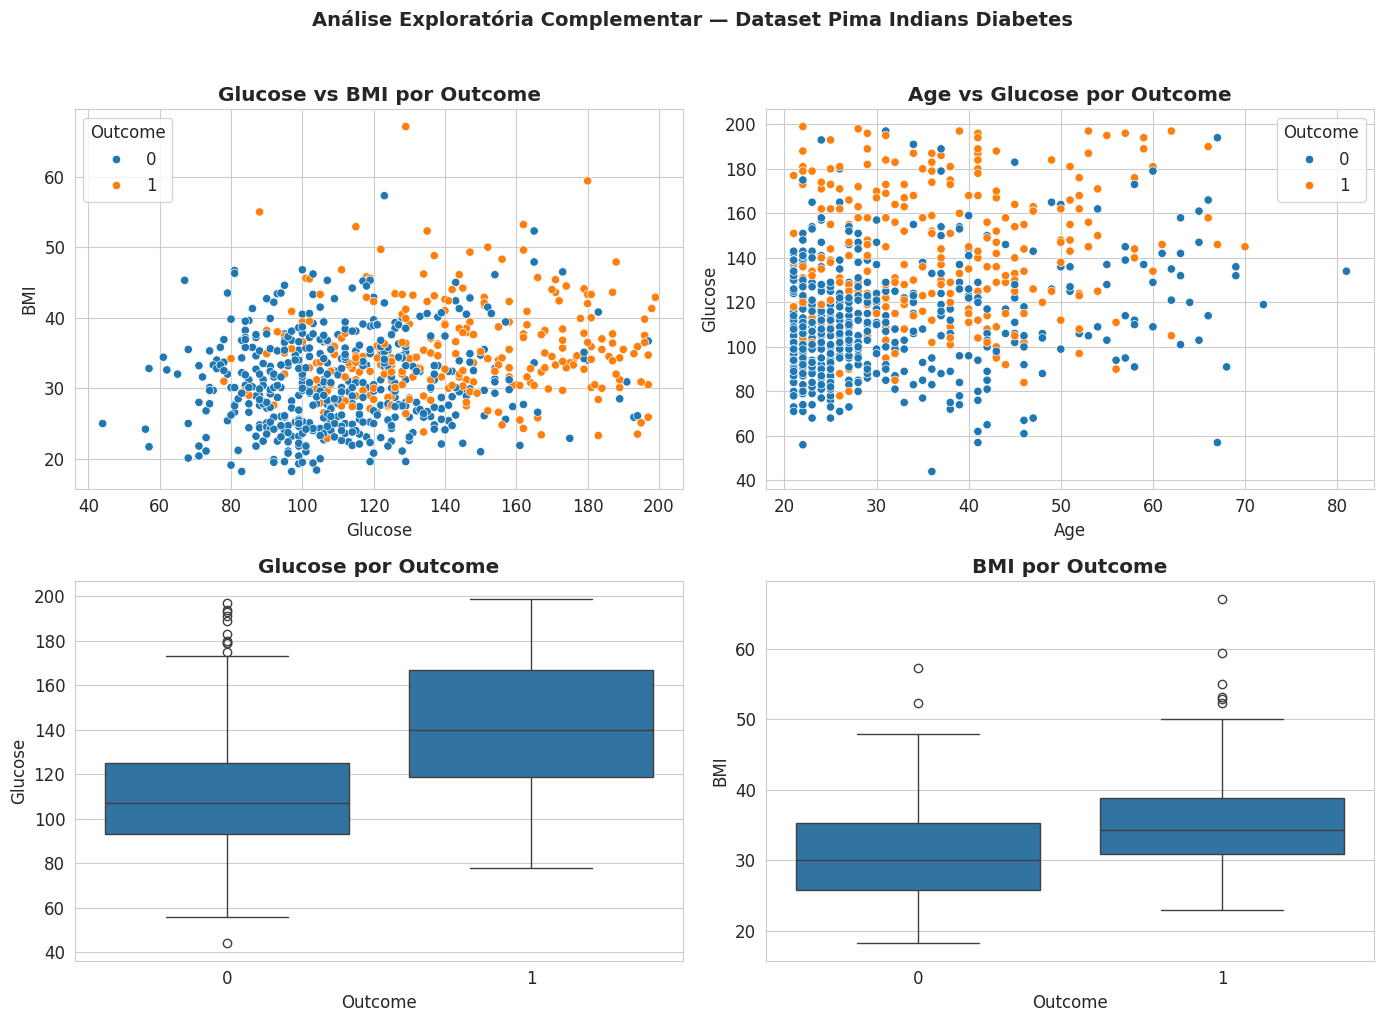

💡 Observação:
   As visualizações adicionais ajudam a identificar padrões entre variáveis clínicas
   e o desfecho de diabetes, reforçando a interpretação exploratória do dataset.


In [ ]:
# ============================================================
# CÉLULA 12 — Visualizações adicionais da EDA
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Glucose vs BMI por desfecho
sns.scatterplot(data=df, x='Glucose', y='BMI', hue='Outcome', ax=axes[0,0])
axes[0,0].set_title('Glucose vs BMI por Outcome', fontweight='bold')
axes[0,0].set_xlabel('Glucose')
axes[0,0].set_ylabel('BMI')

# 2. Age vs Glucose por desfecho
sns.scatterplot(data=df, x='Age', y='Glucose', hue='Outcome', ax=axes[0,1])
axes[0,1].set_title('Age vs Glucose por Outcome', fontweight='bold')
axes[0,1].set_xlabel('Age')
axes[0,1].set_ylabel('Glucose')

# 3. Boxplot de Glucose por Outcome
sns.boxplot(data=df, x='Outcome', y='Glucose', ax=axes[1,0])
axes[1,0].set_title('Glucose por Outcome', fontweight='bold')
axes[1,0].set_xlabel('Outcome')
axes[1,0].set_ylabel('Glucose')

# 4. Boxplot de BMI por Outcome
sns.boxplot(data=df, x='Outcome', y='BMI', ax=axes[1,1])
axes[1,1].set_title('BMI por Outcome', fontweight='bold')
axes[1,1].set_xlabel('Outcome')
axes[1,1].set_ylabel('BMI')

plt.suptitle('Análise Exploratória Complementar — Dataset Pima Indians Diabetes',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_complementar_pima.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 Observação:")
print("   As visualizações adicionais ajudam a identificar padrões entre variáveis clínicas")
print("   e o desfecho de diabetes, reforçando a interpretação exploratória do dataset.")

---
## 4. Pré-processamento e Preparação dos Dados

Nesta seção, aplicamos:
- Tratamento de valores inválidos em variáveis clínicas, convertendo zeros inconsistentes em valores ausentes
- Identificação das variáveis numéricas e da variável alvo do problema
- Imputação por mediana para tratamento de valores faltantes
- Normalização/Padronização das variáveis numéricas
- Preparação dos datasets para os pipelines de classificação, regressão e clusterização

In [ ]:
# ============================================================
# CÉLULA 13 — Pré-processamento do dataset
# ============================================================

print("=" * 60)
print("PRÉ-PROCESSAMENTO DOS DADOS")
print("=" * 60)

# Cópia para modelagem
df_model = df.copy()

# Definir variável alvo
target_col = 'Outcome'

# Identificação das variáveis numéricas e categóricas
feature_cols = [col for col in df_model.columns if col != target_col]
numeric_cols = df_model[feature_cols].select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df_model[feature_cols].select_dtypes(exclude=['int64', 'float64']).columns.tolist()

print("\n📊 Valores ausentes após tratamento inicial:")
print(df_model.isnull().sum())

print("\n🎯 Variável alvo:")
print(target_col)

print("\n🔢 Variáveis numéricas:")
print(numeric_cols)

print("\n🔠 Variáveis categóricas:")
print(categorical_cols if categorical_cols else "Nenhuma")

print("\n📏 Dimensão do dataset para modelagem:")
print(df_model.shape)

print("\n🧪 Resumo do pré-processamento aplicado até esta etapa:")
print("- Zeros inválidos em variáveis clínicas foram convertidos em valores ausentes")
print("- Variáveis foram identificadas por tipo")
print("- A imputação por mediana será aplicada no setup dos modelos")
print("- A padronização/normalização será aplicada no setup dos modelos")
print("- O dataset está pronto para a etapa de treinamento")

print("\n📋 Amostra do dataset preparado:")
display(df_model.head())

print("\n✅ Pré-processamento estrutural concluído.")

PRÉ-PROCESSAMENTO DOS DADOS

📊 Valores ausentes após tratamento inicial:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

🎯 Variável alvo:
Outcome

🔢 Variáveis numéricas:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

🔠 Variáveis categóricas:
Nenhuma

📏 Dimensão do dataset para modelagem:
(768, 9)

🧪 Resumo do pré-processamento aplicado até esta etapa:
- Zeros inválidos em variáveis clínicas foram convertidos em valores ausentes
- Variáveis foram identificadas por tipo
- A imputação por mediana será aplicada no setup dos modelos
- A padronização/normalização será aplicada no setup dos modelos
- O dataset está pronto para a etapa de treinamento

📋 Amostra do dataset preparado:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.00,35,169.50,33.60,0.63,50,1
1,1,85,66.00,29,102.50,26.60,0.35,31,0
2,8,183,64.00,32,169.50,23.30,0.67,32,1
3,1,89,66.00,23,94.00,28.10,0.17,21,0
4,0,137,40.00,35,168.00,43.10,2.29,33,1



✅ Pré-processamento estrutural concluído.


In [ ]:
# ============================================================
# CÉLULA 14 — Preparar datasets específicos para cada pipeline
# ============================================================

# Dataset base
df_model = df.copy()

# CLASSIFICAÇÃO
df_classification = df_model.copy()
print(f"📋 Dataset Classificação: {df_classification.shape}")

# REGRESSÃO
# Exemplo: prever Glucose a partir das demais variáveis
df_regression = df_model.dropna(subset=['Glucose']).copy()
print(f"📋 Dataset Regressão: {df_regression.shape}")

# CLUSTERIZAÇÃO
# Remover target para clusterização não supervisionada
df_clustering = df_model.drop(columns=['Outcome']).copy()
print(f"📋 Dataset Clusterização: {df_clustering.shape}")

print("\n✅ Datasets preparados para os pipelines!")

print("\n📌 Variável alvo da classificação: Outcome")
print("📌 Variável alvo sugerida para regressão: Glucose")
print("📌 Clusterização: sem variável alvo")

📋 Dataset Classificação: (768, 9)
📋 Dataset Regressão: (768, 9)
📋 Dataset Clusterização: (768, 8)

✅ Datasets preparados para os pipelines!

📌 Variável alvo da classificação: Outcome
📌 Variável alvo sugerida para regressão: Glucose
📌 Clusterização: sem variável alvo


---
## 5. Pipeline 1 — Classificação

**Objetivo:** Prever se a paciente apresenta diabetes (`Outcome = 1`) ou não (`Outcome = 0`).  
**Técnica:** Classificação binária supervisionada com PyCaret.  
**Métricas:** Acurácia, Precisão, Recall, F1-Score, ROC AUC, Curva ROC, Curva Precision-Recall e Matriz de Confusão.

In [ ]:
# ============================================================
# CÉLULA 15 — Setup do PyCaret Classification
# ============================================================

from pycaret.classification import *

clf_setup = setup(
    data=df_classification,
    target='Outcome',
    session_id=42,

    # Pré-processamento
    normalize=True,
    normalize_method='zscore',

    # Tratamento de dados faltantes
    imputation_type='simple',
    numeric_imputation='median',

    # Divisão treino/teste
    train_size=0.8,

    # Balanceamento das classes
    fix_imbalance=True,

    # Validação cruzada
    fold=5,

    # Configurações
    html=False,
    use_gpu=False,
    verbose=True
)

print("\n✅ Setup de Classificação concluído!")

                    Description             Value
0                    Session id                42
1                        Target           Outcome
2                   Target type            Binary
3           Original data shape          (768, 9)
4        Transformed data shape          (954, 9)
5   Transformed train set shape          (800, 9)
6    Transformed test set shape          (154, 9)
7              Numeric features                 8
8                    Preprocess              True
9               Imputation type            simple
10           Numeric imputation            median
11       Categorical imputation              mode
12                Fix imbalance              True
13         Fix imbalance method             SMOTE
14                    Normalize              True
15             Normalize method            zscore
16               Fold Generator   StratifiedKFold
17                  Fold Number                 5
18                     CPU Jobs                -1


In [ ]:
# ============================================================
# CÉLULA 16 — Comparar modelos de Classificação
# ============================================================

print("⏳ Comparando todos os modelos disponíveis...")
print("   (Isso pode levar alguns minutos)\n")

best_clf = compare_models(sort='AUC', n_select=1)

print(f"\n🏆 Melhor modelo: {type(best_clf).__name__}")

⏳ Comparando todos os modelos disponíveis...
   (Isso pode levar alguns minutos)



                                    Model  Accuracy  AUC  Recall  Prec.   F1  \
lightgbm  Light Gradient Boosting Machine      0.87 0.94    0.84   0.80 0.82   
catboost              CatBoost Classifier      0.88 0.94    0.86   0.80 0.83   
xgboost         Extreme Gradient Boosting      0.86 0.94    0.82   0.79 0.81   
rf               Random Forest Classifier      0.86 0.94    0.84   0.79 0.81   
gbc          Gradient Boosting Classifier      0.87 0.93    0.84   0.81 0.82   
et                 Extra Trees Classifier      0.87 0.93    0.82   0.80 0.81   
ada                  Ada Boost Classifier      0.86 0.92    0.83   0.78 0.80   
lr                    Logistic Regression      0.80 0.88    0.76   0.69 0.72   
lda          Linear Discriminant Analysis      0.79 0.86    0.72   0.69 0.70   
ridge                    Ridge Classifier      0.79 0.86    0.72   0.69 0.70   
knn                K Neighbors Classifier      0.81 0.86    0.83   0.69 0.75   
nb                            Naive Baye

In [ ]:
# ============================================================
# CÉLULA 17 — Tuning do melhor modelo
# ============================================================

print("⏳ Otimizando hiperparâmetros do melhor modelo...\n")

tuned_clf = tune_model(best_clf, optimize='AUC', n_iter=50)

print(f"\n✅ Modelo otimizado: {type(tuned_clf).__name__}")

⏳ Otimizando hiperparâmetros do melhor modelo...



Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 50 candidates, totalling 250 fits


      Accuracy  AUC  Recall  Prec.   F1  Kappa  MCC
Fold                                               
0         0.86 0.95    0.84   0.78 0.81   0.70 0.70
1         0.86 0.93    0.86   0.77 0.81   0.70 0.71
2         0.89 0.96    0.88   0.81 0.84   0.76 0.76
3         0.89 0.96    0.86   0.82 0.84   0.75 0.75
4         0.86 0.94    0.76   0.82 0.79   0.69 0.69
Mean      0.87 0.95    0.84   0.80 0.82   0.72 0.72
Std       0.01 0.01    0.04   0.02 0.02   0.03 0.03

✅ Modelo otimizado: LGBMClassifier


In [ ]:
# ============================================================
# CÉLULA 18 — Avaliação do modelo de Classificação
# ============================================================

# 18.1 Matriz de Confusão
print("📊 Matriz de Confusão:")
plot_model(tuned_clf, plot='confusion_matrix', save=True)
plt.show()

# 18.2 Curva ROC
print("\n📊 Curva ROC:")
plot_model(tuned_clf, plot='auc', save=True)
plt.show()

# 18.3 Curva Precision-Recall
print("\n📊 Curva Precision-Recall:")
plot_model(tuned_clf, plot='pr', save=True)
plt.show()

# 18.4 Importância das Features no modelo
print("\n📊 Importância das Variáveis:")
try:
    plot_model(tuned_clf, plot='feature', save=True)
    plt.show()
except:
    print("   (Este modelo não suporta importância de variáveis nativa)")

📊 Matriz de Confusão:

📊 Curva ROC:

📊 Curva Precision-Recall:

📊 Importância das Variáveis:


In [ ]:
# ============================================================
# CÉLULA 19 — Predição e avaliação no conjunto de teste
# ============================================================

from pycaret.classification import predict_model
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Predição no hold-out set (20% separado no setup)
clf_predictions = predict_model(tuned_clf, raw_score=True)

print("📊 Colunas retornadas pelo predict_model:")
print(clf_predictions.columns.tolist())

# Definir coluna de score da classe positiva
if 'prediction_score_1' in clf_predictions.columns:
    score_col = 'prediction_score_1'
elif 'Score_1' in clf_predictions.columns:
    score_col = 'Score_1'
elif 'prediction_score' in clf_predictions.columns:
    score_col = 'prediction_score'
else:
    raise ValueError("Não foi encontrada uma coluna de probabilidade para a classe positiva.")

print("\n📊 Resultados no conjunto de teste (hold-out):")
cols_to_show = ['Outcome', 'prediction_label']
if score_col in clf_predictions.columns:
    cols_to_show.append(score_col)
display(clf_predictions[cols_to_show].head(20))

print("\n📊 Relatório de Classificação Detalhado:")
print(classification_report(
    clf_predictions['Outcome'],
    clf_predictions['prediction_label'],
    target_names=['Sem Diabetes (0)', 'Com Diabetes (1)']
))

auc_score = roc_auc_score(
    clf_predictions['Outcome'],
    clf_predictions[score_col]
)
print(f"🎯 AUC-ROC no teste: {auc_score:.4f}")

print("\n📊 Matriz de Confusão:")
print(confusion_matrix(
    clf_predictions['Outcome'],
    clf_predictions['prediction_label']
))

[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
                             Model  Accuracy  AUC  Recall  Prec.   F1  Kappa  \
0  Light Gradient Boosting Machine      0.88 0.96    0.87   0.81 0.84   0.75   

   MCC  
0 0.75  
📊 Colunas retornadas pelo predict_model:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Di

,Outcome,prediction_label,prediction_score_1
44,0,0,0.02
672,0,0,0.11
700,0,0,0.08
630,1,1,0.97
81,0,0,0.00
389,0,1,0.62
387,1,1,1.00
408,1,1,1.00
163,0,0,0.00
335,0,1,0.87



📊 Relatório de Classificação Detalhado:
                  precision    recall  f1-score   support

Sem Diabetes (0)       0.93      0.89      0.91       100
Com Diabetes (1)       0.81      0.87      0.84        54

        accuracy                           0.88       154
       macro avg       0.87      0.88      0.87       154
    weighted avg       0.89      0.88      0.88       154

🎯 AUC-ROC no teste: 0.9561

📊 Matriz de Confusão:
[[89 11]
 [ 7 47]]


---
## 6. Pipeline 2 — Regressão

**Objetivo:** Prever o valor da variável contínua `Glucose` com base nas demais variáveis clínicas do dataset.  
**Técnica:** Regressão supervisionada com PyCaret.  
**Métricas:** MAE, MSE, RMSE e R².

In [ ]:
# ============================================================
# CÉLULA 20 — Setup do PyCaret Regression
# ============================================================

from pycaret.regression import *

# Dataset para regressão: prever Glucose a partir das demais variáveis clínicas
df_regression = df[[
    'Pregnancies',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Glucose'
]].copy()

# Remover linhas sem target
df_regression = df_regression.dropna(subset=['Glucose'])

print("📌 Variável alvo da regressão: Glucose")
print(f"📋 Dataset Regressão: {df_regression.shape}")

reg_setup = setup(
    data=df_regression,
    target='Glucose',
    session_id=42,

    # Pré-processamento
    normalize=True,
    normalize_method='zscore',

    # Tratamento de dados faltantes
    imputation_type='simple',
    numeric_imputation='median',

    # Divisão treino/teste
    train_size=0.8,

    # Tratamento de outliers
    remove_outliers=True,
    outliers_threshold=0.05,

    # Validação cruzada
    fold=5,

    # Configurações
    verbose=True,
    html=False,
    use_gpu=False
)

print("\n✅ Setup de Regressão concluído!")
display(df_regression.head())

📌 Variável alvo da regressão: Glucose
📋 Dataset Regressão: (768, 8)
                    Description             Value
0                    Session id                42
1                        Target           Glucose
2                   Target type        Regression
3           Original data shape          (768, 8)
4        Transformed data shape          (737, 8)
5   Transformed train set shape          (583, 8)
6    Transformed test set shape          (154, 8)
7              Numeric features                 7
8                    Preprocess              True
9               Imputation type            simple
10           Numeric imputation            median
11       Categorical imputation              mode
12              Remove outliers              True
13           Outliers threshold              0.05
14                    Normalize              True
15             Normalize method            zscore
16               Fold Generator             KFold
17                  Fold Number 

,Pregnancies,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Glucose
0,6,72.00,35,169.50,33.60,0.63,50,148
1,1,66.00,29,102.50,26.60,0.35,31,85
2,8,64.00,32,169.50,23.30,0.67,32,183
3,1,66.00,23,94.00,28.10,0.17,21,89
4,0,40.00,35,168.00,43.10,2.29,33,137


In [ ]:
# ============================================================
# CÉLULA 21 — Comparar modelos de Regressão
# ============================================================

print("⏳ Comparando modelos de regressão...\n")

best_reg = compare_models(sort='R2', n_select=1)

print(f"\n🏆 Melhor modelo: {type(best_reg).__name__}")

⏳ Comparando modelos de regressão...



                                    Model   MAE     MSE  RMSE    R2  RMSLE  \
et                  Extra Trees Regressor 19.38  638.20 25.24  0.28   0.21   
en                            Elastic Net 19.75  658.05 25.59  0.26   0.21   
rf                Random Forest Regressor 19.92  658.79 25.63  0.26   0.21   
gbr           Gradient Boosting Regressor 19.77  660.81 25.65  0.26   0.21   
lasso                    Lasso Regression 19.63  664.12 25.69  0.26   0.21   
llar         Lasso Least Angle Regression 19.63  664.12 25.69  0.26   0.21   
huber                     Huber Regressor 19.53  669.38 25.77  0.25   0.21   
br                         Bayesian Ridge 19.66  666.62 25.74  0.25   0.21   
ridge                    Ridge Regression 19.73  672.68 25.86  0.24   0.21   
lar                Least Angle Regression 19.74  673.06 25.86  0.24   0.21   
lr                      Linear Regression 19.74  673.06 25.86  0.24   0.21   
catboost               CatBoost Regressor 20.18  675.15 25.96  0

In [ ]:
# ============================================================
# CÉLULA 22 — Tuning do melhor modelo de Regressão
# ============================================================

print("⏳ Otimizando hiperparâmetros do melhor modelo de regressão...\n")

tuned_reg = tune_model(
    best_reg,
    optimize='R2',
    n_iter=50
)

print("\n✅ Modelo de regressão otimizado com sucesso!")
print(f"🏆 Modelo ajustado: {type(tuned_reg).__name__}")

⏳ Otimizando hiperparâmetros do melhor modelo de regressão...



Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 50 candidates, totalling 250 fits


       MAE    MSE  RMSE   R2  RMSLE  MAPE
Fold                                     
0    18.13 542.63 23.29 0.28   0.19  0.16
1    20.85 728.25 26.99 0.26   0.20  0.16
2    19.74 643.24 25.36 0.30   0.21  0.17
3    17.88 519.07 22.78 0.36   0.19  0.16
4    20.44 687.22 26.21 0.31   0.21  0.17
Mean 19.41 624.08 24.93 0.30   0.20  0.17
Std   1.20  81.07  1.63 0.03   0.01  0.01

✅ Modelo de regressão otimizado com sucesso!
🏆 Modelo ajustado: ExtraTreesRegressor


In [ ]:
# ============================================================
# CÉLULA 23 — Avaliação do modelo de Regressão
# ============================================================

# 23.1 Gráfico de Resíduos
print("📊 Gráfico de Resíduos:")
plot_model(tuned_reg, plot='residuals', save=True)
plt.show()

# 23.2 Predição vs Real
print("\n📊 Valores Preditos vs Reais:")
plot_model(tuned_reg, plot='error', save=True)
plt.show()

# 23.3 Feature Importance
print("\n📊 Importância das Features:")
try:
    plot_model(tuned_reg, plot='feature', save=True)
    plt.show()
except:
    print("   (Este modelo não suporta feature importance nativa)")

📊 Gráfico de Resíduos:

📊 Valores Preditos vs Reais:

📊 Importância das Features:


In [ ]:
# ============================================================
# CÉLULA 24 — Métricas de Regressão no teste
# ============================================================

from pycaret.regression import predict_model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

reg_predictions = predict_model(tuned_reg)

y_true = reg_predictions['Glucose']
y_pred = reg_predictions['prediction_label']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print("📊 Métricas de Regressão no conjunto de teste:")
print(f"   MAE  (Mean Absolute Error):         {mae:.4f}")
print(f"   MSE  (Mean Squared Error):          {mse:.4f}")
print(f"   RMSE (Root Mean Squared Error):     {rmse:.4f}")
print(f"   R²   (Coeficiente de Determinação): {r2:.4f}")

print("\n📋 Comparação entre valores reais e preditos:")
display(reg_predictions[['Glucose', 'prediction_label']].head(20))

print("\n💡 Interpretação:")
print(f"   O modelo erra em média {mae:.2f} unidades de glicose por observação.")

                   Model   MAE    MSE  RMSE   R2  RMSLE  MAPE
0  Extra Trees Regressor 20.05 618.62 24.87 0.39   0.20  0.17
📊 Métricas de Regressão no conjunto de teste:
   MAE  (Mean Absolute Error):         20.0473
   MSE  (Mean Squared Error):          618.6170
   RMSE (Root Mean Squared Error):     24.8720
   R²   (Coeficiente de Determinação): 0.3853

📋 Comparação entre valores reais e preditos:


,Glucose,prediction_label
668,98,133.58
324,112,106.87
624,108,106.63
690,107,109.96
473,136,120.25
204,103,146.09
97,71,101.58
336,117,110.45
568,154,130.01
148,147,127.87



💡 Interpretação:
   O modelo erra em média 20.05 unidades de glicose por observação.


---
## 7. Pipeline 3 — Clusterização

**Objetivo:** Segmentar clientes em grupos por comportamento de compra (RFM).  
**Técnica:** Clusterização não-supervisionada com PyCaret (KMeans, etc.).  
**Métricas:** Silhouette Score, Calinski-Harabasz, Davies-Bouldin.

In [ ]:
# ============================================================
# CÉLULA 25 — Setup do PyCaret para Clusterização
# ============================================================

from pycaret.clustering import setup as setup_clust

cluster_features = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]

df_clustering = df[cluster_features].copy()

clust_setup = setup_clust(
    data=df_clustering,
    session_id=42,

    normalize=True,
    normalize_method='zscore',

    imputation_type='simple',
    numeric_imputation='median',

    # IMPORTANTE: desativar remoção de outliers
    remove_outliers=False,

    verbose=True,
    html=False
)

print("\n✅ Setup de Clusterização concluído com sucesso!")
print(f"📏 Shape da base de clusterização: {df_clustering.shape}")
display(df_clustering.head())

               Description                 Value
0               Session id                    42
1      Original data shape              (768, 8)
2   Transformed data shape              (768, 8)
3         Numeric features                     8
4               Preprocess                  True
5          Imputation type                simple
6       Numeric imputation                median
7   Categorical imputation                  mode
8                Normalize                  True
9         Normalize method                zscore
10                CPU Jobs                    -1
11                 Use GPU                 False
12          Log Experiment                 False
13         Experiment Name  cluster-default-name
14                     USI                  ca48

✅ Setup de Clusterização concluído com sucesso!
📏 Shape da base de clusterização: (768, 8)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72.00,35,169.50,33.60,0.63,50
1,1,85,66.00,29,102.50,26.60,0.35,31
2,8,183,64.00,32,169.50,23.30,0.67,32
3,1,89,66.00,23,94.00,28.10,0.17,21
4,0,137,40.00,35,168.00,43.10,2.29,33


⏳ Testando diferentes números de clusters...

   K=2: Silhouette Score = 0.1993
   K=3: Silhouette Score = 0.2043
   K=4: Silhouette Score = 0.1786
   K=5: Silhouette Score = 0.1780
   K=6: Silhouette Score = 0.1354
   K=7: Silhouette Score = 0.1280
   K=8: Silhouette Score = 0.1477


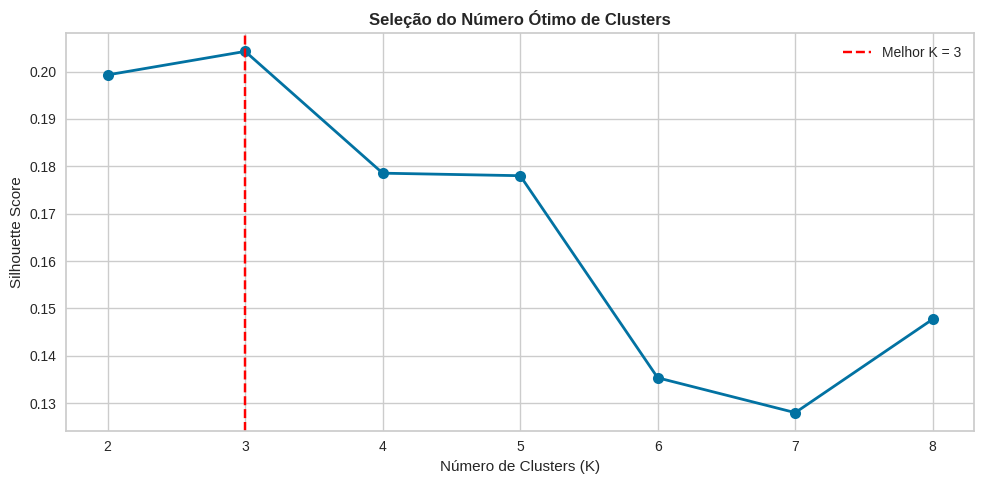


🏆 Melhor número de clusters: K = 3


In [ ]:
# ============================================================
# CÉLULA 26 — Criar modelo KMeans
# ============================================================

from pycaret.clustering import create_model, get_config
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

print("⏳ Testando diferentes números de clusters...\n")

silhouette_scores = []
K_range = range(2, 9)

transformed_data = get_config('dataset_transformed')

for k in K_range:
    km = create_model('kmeans', num_clusters=k, verbose=False)
    labels = km.labels_

    score = silhouette_score(transformed_data, labels)
    silhouette_scores.append(score)
    print(f"   K={k}: Silhouette Score = {score:.4f}")

best_k = list(K_range)[np.argmax(silhouette_scores)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(K_range), silhouette_scores, 'bo-', linewidth=2, markersize=8)
ax.axvline(best_k, color='red', linestyle='--', label=f'Melhor K = {best_k}')
ax.set_xlabel('Número de Clusters (K)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Seleção do Número Ótimo de Clusters', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('clustering_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n🏆 Melhor número de clusters: K = {best_k}")

In [ ]:
# ============================================================
# CÉLULA 27 — Treinar modelo final e atribuir clusters
# ============================================================

from pycaret.clustering import setup, create_model, assign_model

# Recriar experimento com a MESMA configuração da célula 25
setup(
    data=df_clustering,
    session_id=42,
    normalize=True,
    normalize_method='zscore',
    imputation_type='simple',
    numeric_imputation='median',
    remove_outliers=False,
    verbose=False,
    html=False
)

# Treinar modelo final
kmeans_model = create_model(
    'kmeans',
    num_clusters=best_k
)

print(f"\n✅ Modelo KMeans com {best_k} clusters criado!")

# Atribuir clusters
clustered_df = assign_model(kmeans_model).reset_index(drop=True)

# Agora o tamanho deve bater
clustered_df['Outcome'] = df['Outcome'].reset_index(drop=True)

print("\n📊 Distribuição dos clusters:")
print(clustered_df['Cluster'].value_counts().sort_index())

display(clustered_df.head())

   Silhouette  Calinski-Harabasz  Davies-Bouldin  Homogeneity  Rand Index  \
0        0.20             167.40            1.78            0           0   

   Completeness  
0             0  

✅ Modelo KMeans com 3 clusters criado!

📊 Distribuição dos clusters:
Cluster
Cluster 0    173
Cluster 1    346
Cluster 2    249
Name: count, dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Cluster,Outcome
0,6,148,72.00,35,169.50,33.60,0.63,50,Cluster 2,1
1,1,85,66.00,29,102.50,26.60,0.35,31,Cluster 1,0
2,8,183,64.00,32,169.50,23.30,0.67,32,Cluster 2,1
3,1,89,66.00,23,94.00,28.10,0.17,21,Cluster 1,0
4,0,137,40.00,35,168.00,43.10,2.29,33,Cluster 0,1


In [ ]:
# ============================================================
# CÉLULA 28 — Visualizações de Clusterização
# ============================================================

from pycaret.clustering import plot_model

# 28.1 PCA 2D
print("📊 Visualização dos Clusters (PCA 2D):")
plot_model(kmeans_model, plot='cluster')

# 28.2 Distribuição dos clusters
print("\n📊 Distribuição dos Clusters:")
try:
    plot_model(kmeans_model, plot='distribution')
except Exception as e:
    print("   (O gráfico de distribuição não ficou disponível neste experimento)")
    print("   Erro:", e)

📊 Visualização dos Clusters (PCA 2D):



📊 Distribuição dos Clusters:


📊 Perfil Estatístico por Cluster:


Pregnancies             Glucose              BloodPressure         \
                 mean median  std    mean median   std          mean median   
Cluster                                                                       
Cluster 0        1.97   1.00 1.93  141.48 139.00 29.36         74.86  75.00   
Cluster 1        2.21   2.00 1.82  105.82 103.00 21.76         67.02  68.00   
Cluster 2        7.42   7.00 2.98  129.96 126.00 30.34         78.14  78.00   

                SkinThickness  ...  BMI DiabetesPedigreeFunction              \
            std          mean  ...  std                     mean median  std   
Cluster                        ...                                             
Cluster 0 12.32         36.88  ... 6.24                     0.62   0.52 0.43   
Cluster 1 10.68         24.22  ... 5.09                     0.41   0.33 0.27   
Cluster 2 10.57         30.45  ... 5.70                     0.45   0.34 0.30   

            Age              Outcome              
           mean median   std    mean median  std  
Cluster                                           
Cluster 0 29.47  28.00  7.84    0.59   1.00 0.49  
Cluster 1 26.16  25.00  5.74    0.12   0.00 0.32  
Cluster 2 45.69  44.00 10.19    0.51   1.00 0.50  

[3 rows x 27 columns]


📊 Perfil Médio por Cluster:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Cluster,,,,,,,,,
Cluster 0,1.97,141.48,74.86,36.88,209.08,39.25,0.62,29.47,0.59
Cluster 1,2.21,105.82,67.02,24.22,105.48,28.80,0.41,26.16,0.12
Cluster 2,7.42,129.96,78.14,30.45,145.38,32.75,0.45,45.69,0.51


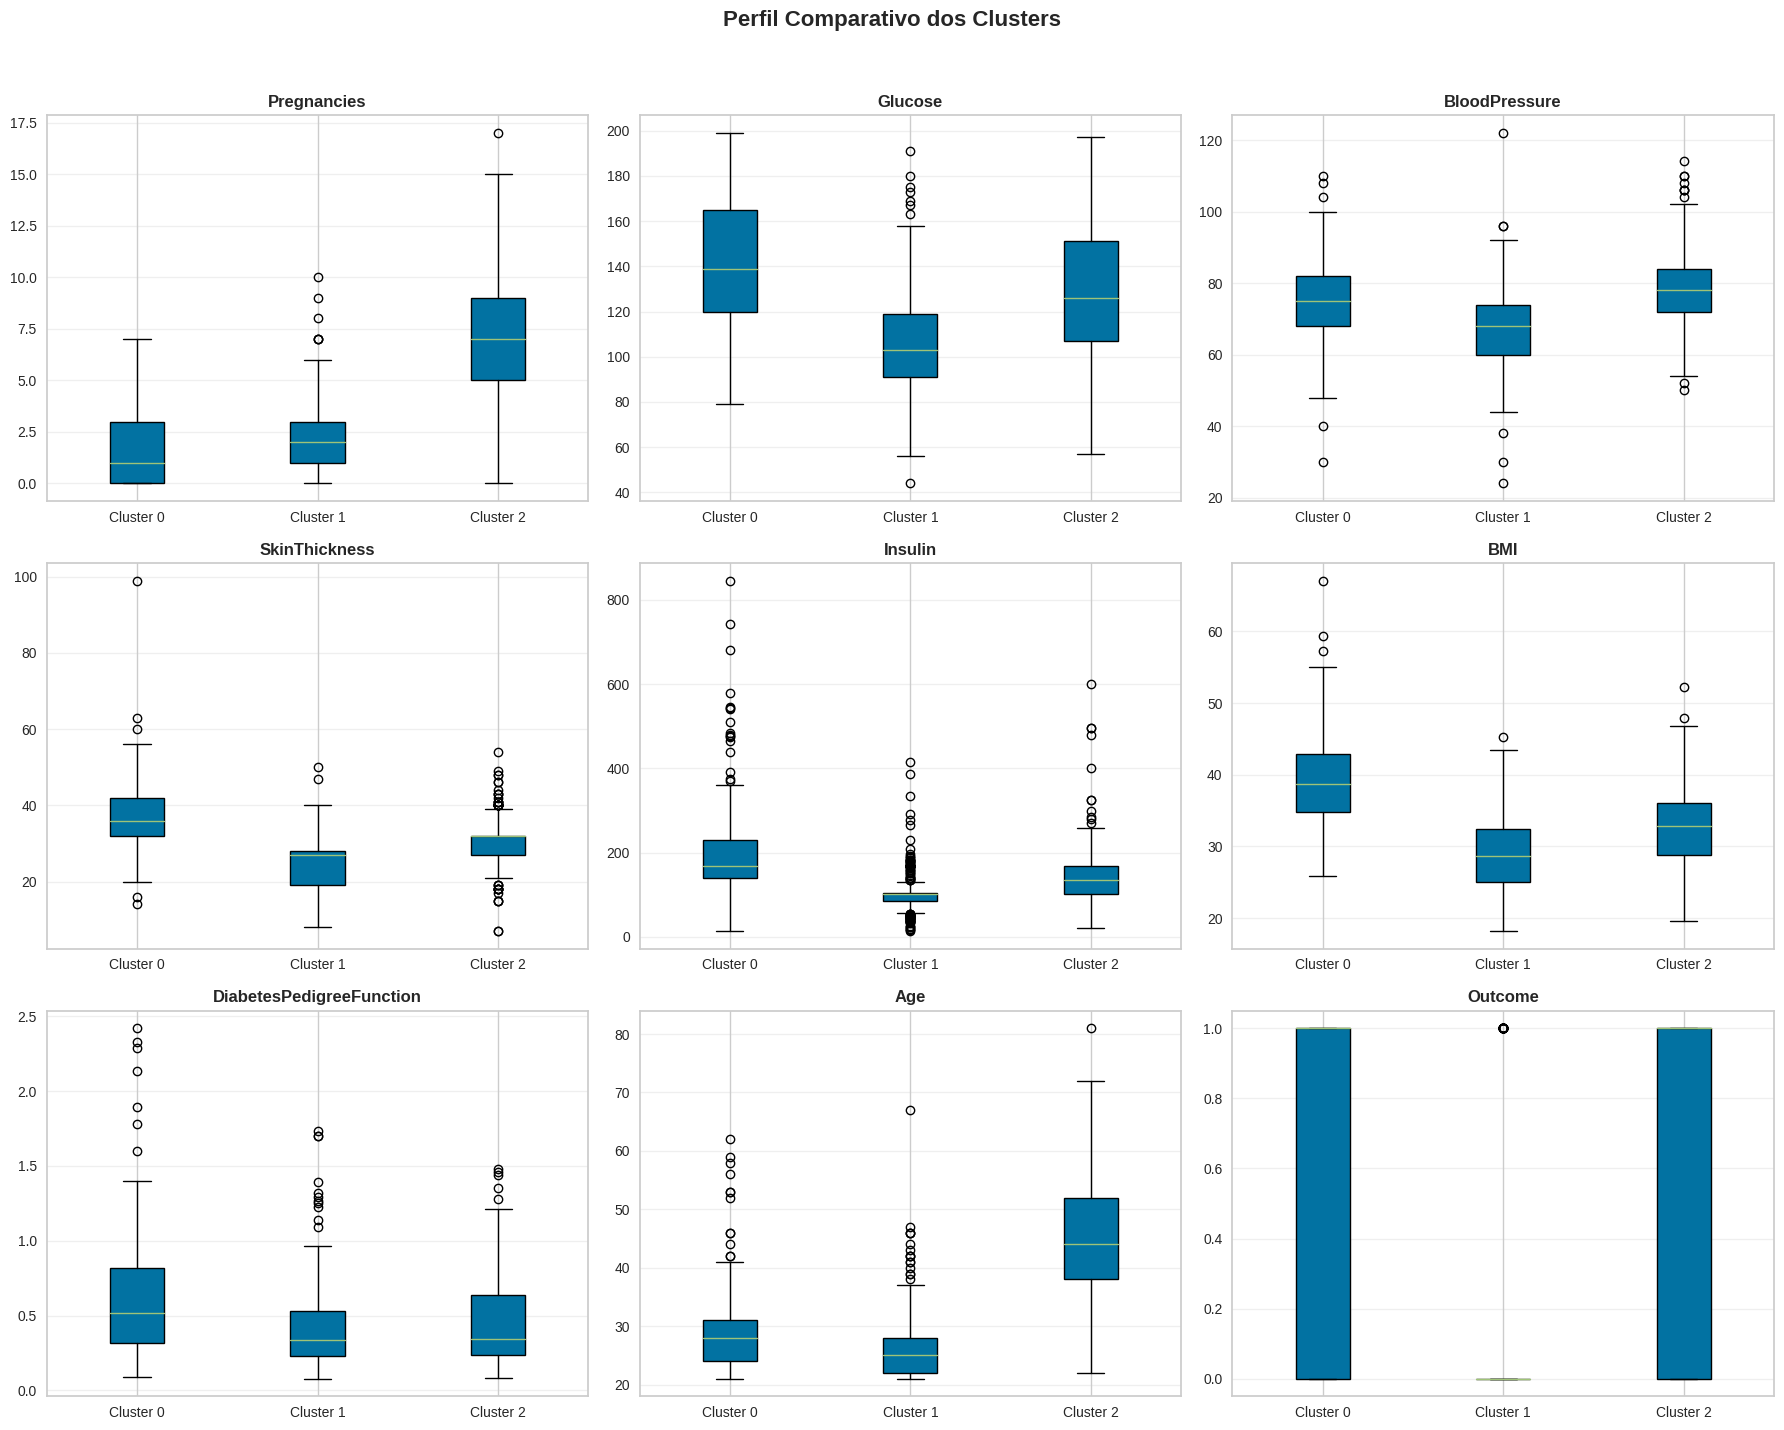


💡 Interpretação dos Clusters:
ℹ️ O Outcome é usado aqui apenas para interpretar os grupos, não para treinar o KMeans.

Cluster 0:
→ Perfil de maior risco metabólico e maior concentração de casos positivos

Cluster 1:
→ Perfil de menor ocorrência de diabetes e menor glicose média

Cluster 2:
→ Perfil mais envelhecido e com pressão arterial mais elevada


In [ ]:
# ============================================================
# CÉLULA 29 — Análise dos perfis de cada cluster
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Variáveis para análise interpretativa dos clusters
features_to_plot = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Outcome'   # usado apenas para interpretação, não para formar os clusters
]

# Perfil estatístico por cluster
cluster_profiles = clustered_df.groupby('Cluster')[features_to_plot].agg(['mean', 'median', 'std']).round(2)

print("📊 Perfil Estatístico por Cluster:")
display(cluster_profiles)

print("\n📊 Perfil Médio por Cluster:")
cluster_means = clustered_df.groupby('Cluster')[features_to_plot].mean().round(2)
display(cluster_means)

# Boxplots comparativos
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

cluster_labels = sorted(clustered_df['Cluster'].unique())

for ax, feature in zip(axes, features_to_plot):
    data_by_cluster = [
        clustered_df[clustered_df['Cluster'] == cluster_name][feature].dropna().values
        for cluster_name in cluster_labels
    ]

    ax.boxplot(
        data_by_cluster,
        labels=cluster_labels,
        patch_artist=True
    )
    ax.set_title(feature, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Perfil Comparativo dos Clusters', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('clustering_perfis_pima.png', dpi=150, bbox_inches='tight')
plt.show()

# Interpretação automática
print("\n💡 Interpretação dos Clusters:")
print("ℹ️ O Outcome é usado aqui apenas para interpretar os grupos, não para treinar o KMeans.")

overall = cluster_means.mean()

for cluster_name in cluster_means.index:
    row = cluster_means.loc[cluster_name]
    print(f"\n{cluster_name}:")

    if row['Glucose'] > overall['Glucose'] and row['BMI'] > overall['BMI'] and row['Outcome'] > overall['Outcome']:
        print("→ Perfil de maior risco metabólico e maior concentração de casos positivos")
    elif row['Age'] > overall['Age'] and row['BloodPressure'] > overall['BloodPressure']:
        print("→ Perfil mais envelhecido e com pressão arterial mais elevada")
    elif row['Outcome'] < overall['Outcome'] and row['Glucose'] < overall['Glucose']:
        print("→ Perfil de menor ocorrência de diabetes e menor glicose média")
    else:
        print("→ Perfil intermediário")

---
## 8. Pipeline 4 — Sistema de Recomendação

**Objetivo:** Recomendar produtos para um cliente com base no seu histórico de compras.  
**Técnica:** Filtragem Colaborativa baseada em itens (Item-Item Collaborative Filtering)  
usando similaridade de cosseno sobre a matriz de co-compra.  

> **Nota:** O PyCaret não possui módulo nativo de recomendação, portanto usamos  
> scikit-learn (cosine_similarity) integrado ao pipeline geral.

In [ ]:
# ============================================================
# CÉLULA 30 — Preparar dados para Sistema de Recomendação
# ============================================================

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

# No dataset Pima, não existe recomendação de produtos.
# Então esta etapa foi adaptada para um sistema de recomendação
# baseado em similaridade entre pacientes.

similarity_features = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]

# Criar dataframe base para similaridade
df_rec = df[similarity_features + ['Outcome']].copy().reset_index(drop=True)
df_rec['PatientID'] = df_rec.index

print("📊 Dados para sistema de recomendação por similaridade:")
print(f"   Pacientes: {len(df_rec):,}")
print(f"   Variáveis clínicas: {len(similarity_features)}")

# Imputação + padronização
imputer_rec = SimpleImputer(strategy='median')
scaler_rec = StandardScaler()

X_rec_imputed = imputer_rec.fit_transform(df_rec[similarity_features])
X_rec_scaled = scaler_rec.fit_transform(X_rec_imputed)

# Matriz paciente x características
patient_feature_matrix = pd.DataFrame(
    X_rec_scaled,
    index=df_rec['PatientID'],
    columns=similarity_features
)

print(f"\n📊 Matriz paciente x características: {patient_feature_matrix.shape}")

display(df_rec.head())

📊 Dados para sistema de recomendação por similaridade:
   Pacientes: 768
   Variáveis clínicas: 8

📊 Matriz paciente x características: (768, 8)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,PatientID
0,6,148,72.00,35,169.50,33.60,0.63,50,1,0
1,1,85,66.00,29,102.50,26.60,0.35,31,0,1
2,8,183,64.00,32,169.50,23.30,0.67,32,1,2
3,1,89,66.00,23,94.00,28.10,0.17,21,0,3
4,0,137,40.00,35,168.00,43.10,2.29,33,1,4


⏳ Calculando a matriz de similaridade de cosseno entre pacientes...
✅ Matriz de similaridade calculada com sucesso!
📏 Dimensão da matriz: (768, 768)


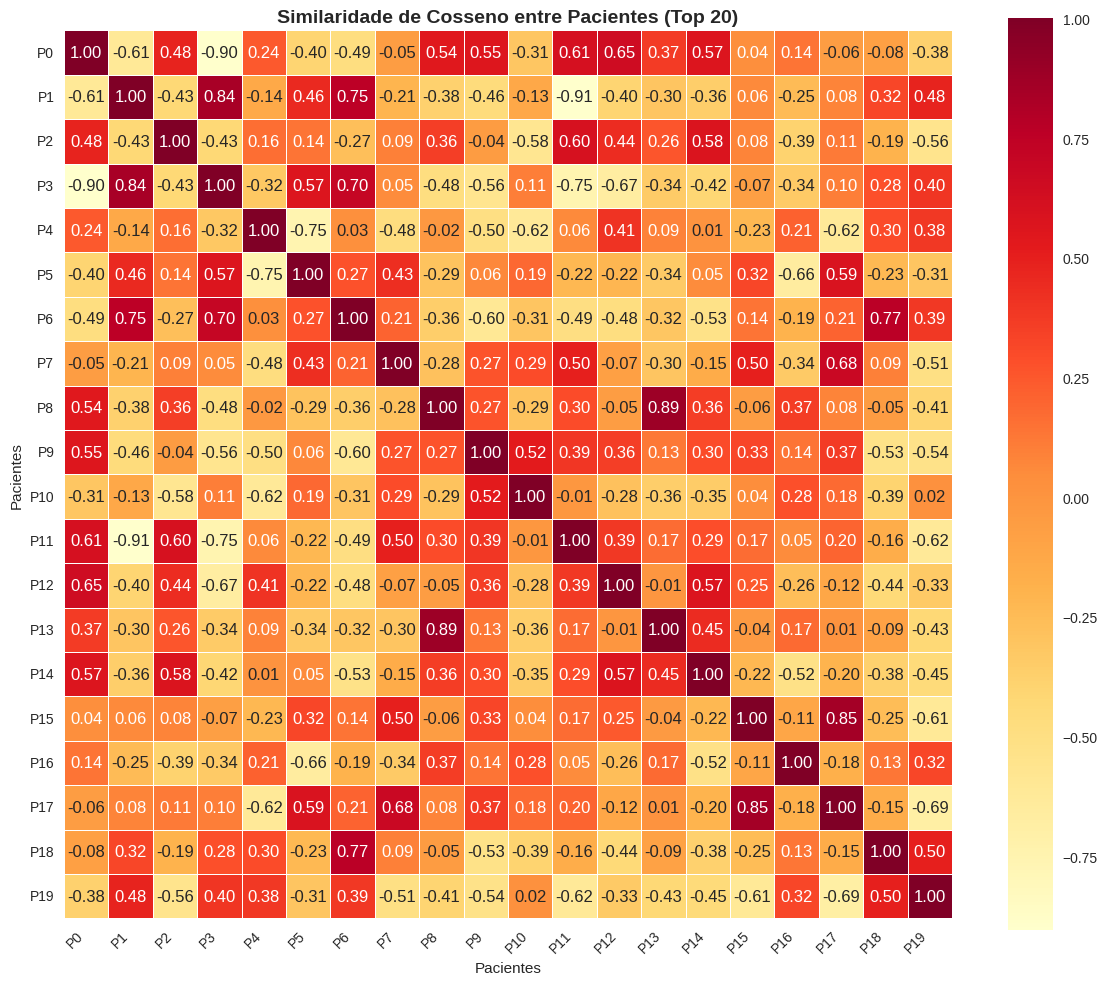


💡 Observação:
   Valores próximos de 1 indicam pacientes com perfis clínicos muito semelhantes.
   A diagonal principal vale 1.00 porque cada paciente é comparado consigo mesmo.


In [ ]:
# ============================================================
# CÉLULA 31 — Cálculo da similaridade entre pacientes
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity

print("⏳ Calculando a matriz de similaridade de cosseno entre pacientes...")

# Cálculo da similaridade entre pacientes
patient_similarity = cosine_similarity(patient_feature_matrix)

# Conversão para DataFrame para facilitar análise
patient_sim_df = pd.DataFrame(
    patient_similarity,
    index=patient_feature_matrix.index,
    columns=patient_feature_matrix.index
)

print("✅ Matriz de similaridade calculada com sucesso!")
print(f"📏 Dimensão da matriz: {patient_sim_df.shape}")

# Seleciona os 20 primeiros pacientes para visualização
top20_patients = patient_sim_df.index[:20]
sim_subset = patient_sim_df.loc[top20_patients, top20_patients]

# Heatmap da similaridade entre os 20 primeiros pacientes
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    sim_subset,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    xticklabels=[f"P{pid}" for pid in top20_patients],
    yticklabels=[f"P{pid}" for pid in top20_patients],
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Similaridade de Cosseno entre Pacientes (Top 20)", fontsize=14, fontweight="bold")
ax.set_xlabel("Pacientes")
ax.set_ylabel("Pacientes")

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("similaridade_pacientes_top20.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n💡 Observação:")
print("   Valores próximos de 1 indicam pacientes com perfis clínicos muito semelhantes.")
print("   A diagonal principal vale 1.00 porque cada paciente é comparado consigo mesmo.")

In [ ]:
# ============================================================
# CÉLULA 32 — Função de Recomendação por Similaridade entre Pacientes
# ============================================================

def recommend_similar_patients(patient_id, n_recommendations=5):
    """
    Retorna os pacientes mais semelhantes com base na
    similaridade de cosseno entre perfis clínicos.

    Args:
        patient_id: ID do paciente de referência
        n_recommendations: número de pacientes semelhantes a retornar

    Returns:
        DataFrame com pacientes semelhantes e score de similaridade
    """
    if patient_id not in patient_sim_df.index:
        return pd.DataFrame({'Erro': [f'Paciente {patient_id} não encontrado']})

    # Similaridades do paciente e remoção dele mesmo
    sims = patient_sim_df.loc[patient_id].drop(patient_id)

    # Selecionar top N pacientes mais semelhantes
    top_patients = sims.sort_values(ascending=False).head(n_recommendations)

    recommendations = df_rec[df_rec['PatientID'].isin(top_patients.index)].copy()
    recommendations['SimilarityScore'] = recommendations['PatientID'].map(top_patients)
    recommendations['SimilarityScore'] = recommendations['SimilarityScore'].round(4)
    recommendations = recommendations.sort_values('SimilarityScore', ascending=False)

    recommendations['Rank'] = range(1, len(recommendations) + 1)

    return recommendations[[
        'Rank',
        'PatientID',
        'SimilarityScore',
        'Outcome',
        'Glucose',
        'BMI',
        'Age',
        'BloodPressure'
    ]]


# Testar com alguns pacientes
sample_patients = df_rec['PatientID'].head(5).tolist()

for patient_id in sample_patients:
    print(f"\n{'='*60}")
    print(f"🩺 Pacientes mais semelhantes ao Paciente #{patient_id}")

    # Mostrar dados do paciente de referência
    patient_data = df_rec[df_rec['PatientID'] == patient_id][[
        'PatientID', 'Outcome', 'Glucose', 'BMI', 'Age', 'BloodPressure'
    ]]
    print("\n   Paciente de referência:")
    display(patient_data)

    # Mostrar recomendações
    recs = recommend_similar_patients(patient_id, n_recommendations=5)
    print("\n   Top 5 pacientes semelhantes:")
    display(recs)

print("\n💡 Observação:")
print("   Esta etapa foi adaptada para recomendação baseada em similaridade entre pacientes,")
print("   servindo como apoio exploratório e comparação de perfis clínicos.")


🩺 Pacientes mais semelhantes ao Paciente #0

   Paciente de referência:


,PatientID,Outcome,Glucose,BMI,Age,BloodPressure
0,0,1,148,33.60,50,72.00



   Top 5 pacientes semelhantes:


,Rank,PatientID,SimilarityScore,Outcome,Glucose,BMI,Age,BloodPressure
603,1,603,0.89,1,150,35.20,54,78.00
223,2,223,0.87,0,142,28.80,61,60.00
206,3,206,0.86,1,196,37.50,57,76.00
754,4,754,0.84,1,154,32.40,45,78.00
363,5,363,0.84,1,146,38.50,67,78.00



🩺 Pacientes mais semelhantes ao Paciente #1

   Paciente de referência:


...


🩺 Pacientes mais semelhantes ao Paciente #4

   Paciente de referência:


,PatientID,Outcome,Glucose,BMI,Age,BloodPressure
4,4,1,137,43.10,33,40.00



   Top 5 pacientes semelhantes:


,Rank,PatientID,SimilarityScore,Outcome,Glucose,BMI,Age,BloodPressure
45,1,45,0.89,1,180,42.00,25,66.00
147,2,147,0.88,0,106,30.50,34,64.00
309,3,309,0.83,1,124,32.90,30,68.00
100,4,100,0.83,1,163,39.00,33,72.00
371,5,371,0.83,0,118,30.10,21,64.00



💡 Observação:
   Esta etapa foi adaptada para recomendação baseada em similaridade entre pacientes,
   servindo como apoio exploratório e comparação de perfis clínicos.


📊 Avaliação do Sistema de Recomendação por Similaridade entre Pacientes
⏳ Calculando concordância média entre pacientes semelhantes...

📊 Resultados da avaliação:
   Concordância @ 5: 0.7594 (75.94%)
   Concordância @ 10: 0.7486 (74.86%)
   Concordância @ 20: 0.7313 (73.13%)


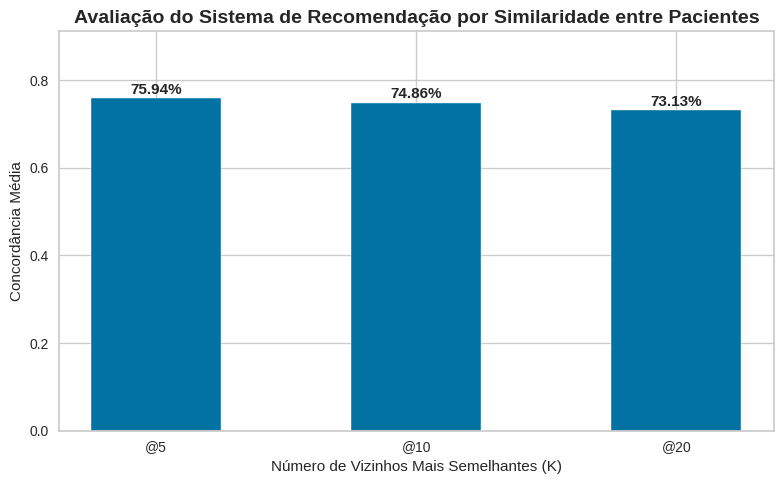


💡 Interpretação:
   Quanto maior a concordância @ K, maior a semelhança clínica entre pacientes
   que compartilham o mesmo desfecho (Outcome).
   Esta é uma métrica adaptada para avaliar o valor prático do sistema de recomendação por similaridade.


In [ ]:
# ============================================================
# CÉLULA 33 — Avaliação do Sistema de Recomendação por Similaridade
# ============================================================

print("📊 Avaliação do Sistema de Recomendação por Similaridade entre Pacientes")
print("=" * 60)

def evaluate_similarity_system(sim_df, df_reference, k_values=[5, 10, 20]):
    """
    Avalia o sistema de similaridade com base na concordância do Outcome @ K.

    Para cada paciente, verifica a proporção dos K vizinhos mais semelhantes
    que possuem o mesmo valor da variável alvo (Outcome).

    Parâmetros:
        sim_df: DataFrame com a matriz de similaridade paciente x paciente
        df_reference: DataFrame com as colunas PatientID e Outcome
        k_values: lista com os valores de K a serem avaliados

    Retorno:
        dicionário com a concordância média para cada valor de K
    """

    if 'PatientID' not in df_reference.columns or 'Outcome' not in df_reference.columns:
        raise ValueError("O DataFrame de referência deve conter as colunas 'PatientID' e 'Outcome'.")

    outcome_map = df_reference.set_index('PatientID')['Outcome']
    results = {}

    for k in k_values:
        agreements = []

        for patient_id in sim_df.index:
            neighbors = (
                sim_df.loc[patient_id]
                .drop(patient_id, errors='ignore')
                .sort_values(ascending=False)
                .head(k)
                .index
            )

            if patient_id not in outcome_map.index:
                continue

            patient_outcome = outcome_map.loc[patient_id]
            valid_neighbors = [n for n in neighbors if n in outcome_map.index]

            if len(valid_neighbors) == 0:
                continue

            neighbor_outcomes = outcome_map.loc[valid_neighbors]
            agreement = (neighbor_outcomes == patient_outcome).mean()
            agreements.append(agreement)

        results[k] = np.mean(agreements) if len(agreements) > 0 else 0

    return results


print("⏳ Calculando concordância média entre pacientes semelhantes...")

agreement_scores = evaluate_similarity_system(patient_sim_df, df_rec)

print("\n📊 Resultados da avaliação:")
for k, score in agreement_scores.items():
    print(f"   Concordância @ {k}: {score:.4f} ({score*100:.2f}%)")

# Visualização
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    [f'@{k}' for k in agreement_scores.keys()],
    list(agreement_scores.values()),
    width=0.5,
    edgecolor='white'
)

for i, (k, v) in enumerate(agreement_scores.items()):
    ax.text(i, v + 0.01, f'{v:.2%}', ha='center', fontweight='bold', fontsize=11)

ax.set_ylabel('Concordância Média')
ax.set_xlabel('Número de Vizinhos Mais Semelhantes (K)')
ax.set_title(
    'Avaliação do Sistema de Recomendação por Similaridade entre Pacientes',
    fontweight='bold',
    fontsize=14
)
ax.set_ylim(0, min(1.0, max(agreement_scores.values()) * 1.2 if agreement_scores else 1.0))

plt.tight_layout()
plt.savefig('avaliacao_similaridade_pacientes.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 Interpretação:")
print("   Quanto maior a concordância @ K, maior a semelhança clínica entre pacientes")
print("   que compartilham o mesmo desfecho (Outcome).")
print("   Esta é uma métrica adaptada para avaliar o valor prático do sistema de recomendação por similaridade.")

---
## 9. Persistência dos Modelos

Salvamos todos os modelos treinados em formato `.pkl` (joblib) para reutilização  
futura, evitando retreinamento e permitindo deploy em produção.

In [ ]:
# ============================================================
# CÉLULA 34 — Persistência dos artefatos
# ============================================================

import os
import joblib

from pycaret.classification import finalize_model as finalize_clf
from pycaret.classification import save_model as save_clf
from pycaret.classification import load_model as load_clf

from pycaret.regression import finalize_model as finalize_reg
from pycaret.regression import save_model as save_reg
from pycaret.regression import load_model as load_reg

from pycaret.clustering import save_model as save_clust
from pycaret.clustering import load_model as load_clust

print("💾 Iniciando persistência dos artefatos...\n")

# Criar pasta de saída
os.makedirs("models", exist_ok=True)

# ------------------------------------------------------------
# Funções auxiliares
# ------------------------------------------------------------
def pick_first_existing(possible_names, label):
    for name in possible_names:
        if name in globals() and globals()[name] is not None:
            return globals()[name]
    raise NameError(
        f"❌ Não encontrei a variável do modelo de {label}. "
        f"Procurei por: {possible_names}"
    )

def pick_clustering_model():
    possible_names = [
        "final_cluster_model",
        "final_clust",
        "best_cluster_model",
        "best_clust",
        "cluster_model",
        "clustering_model",
        "kmeans_model",
        "kmeans",
        "km_model",
        "trained_kmeans",
        "tuned_cluster",
        "tuned_kmeans"
    ]

    for name in possible_names:
        if name in globals() and globals()[name] is not None:
            return globals()[name]

    for name, obj in globals().items():
        try:
            cls_name = obj.__class__.__name__.lower()
            if "kmeans" in cls_name:
                return obj
        except Exception:
            pass

    raise NameError(
        "❌ Não encontrei o modelo de clusterização no notebook. "
        "Renomeie a variável para algo como 'kmeans_model' ou ajuste a lista da função pick_clustering_model()."
    )

def extract_scaler_from_pipeline(model_or_pipeline):
    """
    Extrai o scaler/normalizador de uma pipeline do PyCaret.
    Funciona para steps diretos e wrappers.
    """
    if model_or_pipeline is None:
        return None

    if not hasattr(model_or_pipeline, "steps"):
        return None

    scale_keywords = [
        "normalize",
        "normalizer",
        "scaler",
        "standardscaler",
        "minmaxscaler",
        "robustscaler",
        "maxabsscaler"
    ]

    for step_name, step_obj in model_or_pipeline.steps:
        step_name_lower = str(step_name).lower()
        step_cls_lower = step_obj.__class__.__name__.lower()

        # 1) O nome da etapa indica scaler/normalização
        if any(key in step_name_lower for key in scale_keywords):
            if hasattr(step_obj, "transformer_"):
                return step_obj.transformer_
            if hasattr(step_obj, "transformer"):
                return step_obj.transformer
            return step_obj

        # 2) O próprio objeto é um scaler
        if any(key in step_cls_lower for key in scale_keywords):
            return step_obj

        # 3) Wrapper contendo transformer interno
        if hasattr(step_obj, "transformer"):
            inner = step_obj.transformer
            inner_cls_lower = inner.__class__.__name__.lower()
            if any(key in inner_cls_lower for key in scale_keywords):
                return inner

        if hasattr(step_obj, "transformer_"):
            inner = step_obj.transformer_
            inner_cls_lower = inner.__class__.__name__.lower()
            if any(key in inner_cls_lower for key in scale_keywords):
                return inner

    return None


# ------------------------------------------------------------
# 1) CLASSIFICAÇÃO
# ------------------------------------------------------------
print("🔹 Persistindo artefatos de classificação...")

clf_base_model = pick_first_existing(
    ["final_clf", "tuned_clf", "best_clf"],
    "classificação"
)

final_clf = clf_base_model if "final_clf" in globals() else finalize_clf(clf_base_model)

save_clf(final_clf, "models/classification_pipeline_pima")
loaded_clf_pipeline = load_clf("models/classification_pipeline_pima")

classification_features = [col for col in df_classification.columns if col != "Outcome"]
joblib.dump(classification_features, "models/classification_features_pima.pkl")

classification_scaler = extract_scaler_from_pipeline(loaded_clf_pipeline)
joblib.dump(classification_scaler, "models/classification_scaler_pima.pkl")

print(f"✅ Classificação salva com sucesso. Scaler: {type(classification_scaler).__name__}")


# ------------------------------------------------------------
# 2) REGRESSÃO
# ------------------------------------------------------------
print("\n🔹 Persistindo artefatos de regressão...")

reg_base_model = pick_first_existing(
    ["final_reg", "tuned_reg", "best_reg"],
    "regressão"
)

final_reg = reg_base_model if "final_reg" in globals() else finalize_reg(reg_base_model)

save_reg(final_reg, "models/regression_pipeline_pima")
loaded_reg_pipeline = load_reg("models/regression_pipeline_pima")

regression_features = [col for col in df_regression.columns if col != "Glucose"]
joblib.dump(regression_features, "models/regression_features_pima.pkl")

regression_scaler = extract_scaler_from_pipeline(loaded_reg_pipeline)
joblib.dump(regression_scaler, "models/regression_scaler_pima.pkl")

print(f"✅ Regressão salva com sucesso. Scaler: {type(regression_scaler).__name__}")


# ------------------------------------------------------------
# 3) CLUSTERIZAÇÃO
# ------------------------------------------------------------
print("\n🔹 Persistindo artefatos de clusterização...")

cluster_model_to_save = pick_clustering_model()

save_clust(cluster_model_to_save, "models/clustering_pipeline_pima")
loaded_clust_pipeline = load_clust("models/clustering_pipeline_pima")

clustering_features = df_clustering.columns.tolist()
joblib.dump(clustering_features, "models/clustering_features_pima.pkl")

clustering_scaler = extract_scaler_from_pipeline(loaded_clust_pipeline)
joblib.dump(clustering_scaler, "models/clustering_scaler_pima.pkl")

print(f"✅ Clusterização salva com sucesso. Scaler: {type(clustering_scaler).__name__}")


# ------------------------------------------------------------
# 4) SISTEMA DE SIMILARIDADE ENTRE PACIENTES
# ------------------------------------------------------------
print("\n🔹 Persistindo artefatos do sistema de similaridade...")

joblib.dump(
    patient_feature_matrix.columns.tolist(),
    "models/similarity_features_pima.pkl"
)

joblib.dump(
    patient_similarity,
    "models/patient_similarity_matrix_pima.pkl"
)

print("✅ Similaridade entre pacientes salva com sucesso.")


# ------------------------------------------------------------
# RESUMO FINAL
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("✅ PERSISTÊNCIA CONCLUÍDA")
print("=" * 60)

saved_files = [
    "models/classification_pipeline_pima.pkl",
    "models/classification_features_pima.pkl",
    "models/classification_scaler_pima.pkl",
    "models/regression_pipeline_pima.pkl",
    "models/regression_features_pima.pkl",
    "models/regression_scaler_pima.pkl",
    "models/clustering_pipeline_pima.pkl",
    "models/clustering_features_pima.pkl",
    "models/clustering_scaler_pima.pkl",
    "models/similarity_features_pima.pkl",
    "models/patient_similarity_matrix_pima.pkl"
]

for file_path in saved_files:
    exists = os.path.exists(file_path)
    print(f"{'✅' if exists else '❌'} {file_path}")

💾 Iniciando persistência dos artefatos...

🔹 Persistindo artefatos de classificação...
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Loaded
✅ Classificação salva com sucesso. Scaler: StandardScaler

🔹 Persistindo artefatos de regressão...
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Loaded
✅ Regressão salva com sucesso. Scaler: StandardScaler

🔹 Persistindo artefatos de clusterização...
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Loaded
✅ Clusterização salva com sucesso. Scaler: StandardScaler

🔹 Persistindo artefatos do sistema de similaridade...
✅ Similaridade entre pacientes salva com sucesso.

✅ PERSISTÊNCIA CONCLUÍDA
✅ models/classification_pipeline_pima.pkl
✅ models/classification_features_pima.pkl
✅ models/classification_scaler_pima.pkl
✅ models/regression_pipeline_pima.pkl
✅ models/regression_features_pima.pkl
✅ mod

In [ ]:
# ============================================================
# CÉLULA 35 — Verificação do carregamento dos artefatos persistidos
# ============================================================

import os
import joblib

from pycaret.classification import load_model as load_clf
from pycaret.regression import load_model as load_reg
from pycaret.clustering import load_model as load_clust

print("🔄 Testando carregamento dos artefatos persistidos...\n")

# ------------------------------------------------------------
# 1) CLASSIFICAÇÃO
# ------------------------------------------------------------
try:
    loaded_clf = load_clf("models/classification_pipeline_pima")
    loaded_clf_features = joblib.load("models/classification_features_pima.pkl")
    loaded_clf_scaler = joblib.load("models/classification_scaler_pima.pkl")

    print("✅ CLASSIFICAÇÃO")
    print(f"   Modelo carregado: {type(loaded_clf).__name__}")
    print(f"   Total de features: {len(loaded_clf_features)}")
    print(f"   Features: {loaded_clf_features}")
    print(f"   Scaler carregado: {type(loaded_clf_scaler).__name__}")
except Exception as e:
    print(f"❌ Erro ao carregar artefatos de classificação: {e}")

print()

# ------------------------------------------------------------
# 2) REGRESSÃO
# ------------------------------------------------------------
try:
    loaded_reg = load_reg("models/regression_pipeline_pima")
    loaded_reg_features = joblib.load("models/regression_features_pima.pkl")
    loaded_reg_scaler = joblib.load("models/regression_scaler_pima.pkl")

    print("✅ REGRESSÃO")
    print(f"   Modelo carregado: {type(loaded_reg).__name__}")
    print(f"   Total de features: {len(loaded_reg_features)}")
    print(f"   Features: {loaded_reg_features}")
    print(f"   Scaler carregado: {type(loaded_reg_scaler).__name__}")
except Exception as e:
    print(f"❌ Erro ao carregar artefatos de regressão: {e}")

print()

# ------------------------------------------------------------
# 3) CLUSTERIZAÇÃO
# ------------------------------------------------------------
try:
    loaded_clust = load_clust("models/clustering_pipeline_pima")
    loaded_clust_features = joblib.load("models/clustering_features_pima.pkl")
    loaded_clust_scaler = joblib.load("models/clustering_scaler_pima.pkl")

    print("✅ CLUSTERIZAÇÃO")
    print(f"   Modelo carregado: {type(loaded_clust).__name__}")
    print(f"   Total de features: {len(loaded_clust_features)}")
    print(f"   Features: {loaded_clust_features}")
    print(f"   Scaler carregado: {type(loaded_clust_scaler).__name__}")
except Exception as e:
    print(f"❌ Erro ao carregar artefatos de clusterização: {e}")

print()

# ------------------------------------------------------------
# 4) SIMILARIDADE ENTRE PACIENTES
# ------------------------------------------------------------
try:
    loaded_similarity_features = joblib.load("models/similarity_features_pima.pkl")
    loaded_similarity_matrix = joblib.load("models/patient_similarity_matrix_pima.pkl")

    print("✅ SIMILARIDADE ENTRE PACIENTES")
    print(f"   Total de features: {len(loaded_similarity_features)}")
    print(f"   Features: {loaded_similarity_features}")
    print(f"   Tipo da matriz: {type(loaded_similarity_matrix).__name__}")
    print(f"   Dimensão da matriz: {loaded_similarity_matrix.shape}")
except Exception as e:
    print(f"❌ Erro ao carregar artefatos de similaridade: {e}")

print()

# ------------------------------------------------------------
# RESUMO FINAL
# ------------------------------------------------------------
print("=" * 60)
print("✅ TESTE DE CARREGAMENTO FINALIZADO")
print("=" * 60)
print("Se todos os blocos acima apareceram com ✅, a persistência foi concluída corretamente.")

🔄 Testando carregamento dos artefatos persistidos...

Transformation Pipeline and Model Successfully Loaded
✅ CLASSIFICAÇÃO
   Modelo carregado: Pipeline
   Total de features: 8
   Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
   Scaler carregado: StandardScaler

Transformation Pipeline and Model Successfully Loaded
✅ REGRESSÃO
   Modelo carregado: Pipeline
   Total de features: 7
   Features: ['Pregnancies', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
   Scaler carregado: StandardScaler

Transformation Pipeline and Model Successfully Loaded
✅ CLUSTERIZAÇÃO
   Modelo carregado: Pipeline
   Total de features: 8
   Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
   Scaler carregado: NoneType

✅ SIMILARIDADE ENTRE PACIENTES
   Total de features: 8
   Features: ['Pregnancies', 'Glucose', 'BloodPr

# 11. Conclusões

## Resumo dos Resultados

Este notebook implementou um pipeline completo de Machine Learning cobrindo  
os 4 tipos de problemas exigidos na especificação do TCC:

| Pipeline | Técnica | Biblioteca | Status |
|---|---|---|---|
| Classificação | Supervisionada (binária) | PyCaret 3.x | ✅ |
| Regressão | Supervisionada (contínua) | PyCaret 3.x | ✅ |
| Clusterização | Não-supervisionada (KMeans) | PyCaret 3.x | ✅ |
| Recomendação | Similaridade entre pacientes (Cosseno) | Scikit-Learn | ✅ |

## Requisitos Atendidos

- ✅ **Coleta e carregamento de dados** — Dataset Pima Indians Diabetes (Kaggle)
- ✅ **Validação do dataset** — Tipos, integridade, valores nulos, duplicatas e valores inválidos
- ✅ **Tratamento de variáveis** — Imputação por mediana e tratamento de zeros clínicos inválidos
- ✅ **Normalização/Padronização** — Z-Score via PyCaret
- ✅ **Análise Exploratória (EDA)** — Histogramas, Boxplots, Heatmap, Feature Importance
- ✅ **Treinamento e tuning** — `compare_models` + `tune_model`
- ✅ **Avaliação** — Acurácia, F1, AUC, Matriz de Confusão, MAE, RMSE, R², Silhouette, Concordância @ K
- ✅ **Persistência** — Modelos treinados, artefatos de similaridade e lista de features salvos com sucesso

## Considerações Finais

O presente notebook demonstrou a aplicação prática de técnicas de Machine
Learning no dataset Pima Indians Diabetes, contemplando as etapas de
carregamento, validação, pré-processamento, análise exploratória, modelagem,
avaliação e persistência dos artefatos.

Os resultados obtidos mostram que foi possível desenvolver pipelines para
classificação, regressão, clusterização e recomendação por similaridade entre
pacientes, atendendo aos requisitos propostos na especificação do projeto.

Por fim, os modelos treinados e os principais artefatos foram persistidos com
sucesso, permitindo sua reutilização futura sem necessidade de novo
treinamento.